# ARTICLE'S MAIN CODES

#### necessary versions of the libraries

In [ ]:
pip install numpy==1.23

In [ ]:
pip install tsfresh==0.20.3 

In [ ]:
pip install pandas==1.5.3 

In [ ]:
pip install scipy==1.7.3

# MAIN CODES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from numpy import mean, std
from scipy.stats import shapiro, normaltest, anderson, probplot

from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    cross_val_score,
    RepeatedKFold,
    train_test_split
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding, SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.pipeline import Pipeline
from gtda.plotting import plot_point_cloud


In [2]:
# Load the file for time series
data_path = 'TRIAL_SET_1_GM1ts.csv'
data = pd.read_csv(data_path)

In [3]:
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

### STOP HERE FOR ITERATION PURPOSES

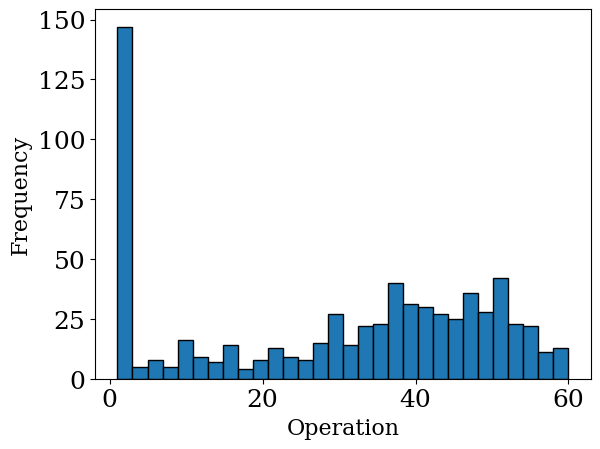

Skewness: -0.33394246598016214
Kurtosis: -1.3275634226201662


In [4]:
import matplotlib.pyplot as plt

# Plot the histogram for the 'Operation' column
plt.hist(data['Operation'], bins=30, edgecolor='black')
plt.xlabel('Operation')
plt.ylabel('Frequency')


# Save the figure as an SVG file
plt.savefig("hist_H1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

# Calculate skewness and kurtosis
skewness = data['Operation'].skew()
kurtosis = data['Operation'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)


## PART I DECOMPOSITION

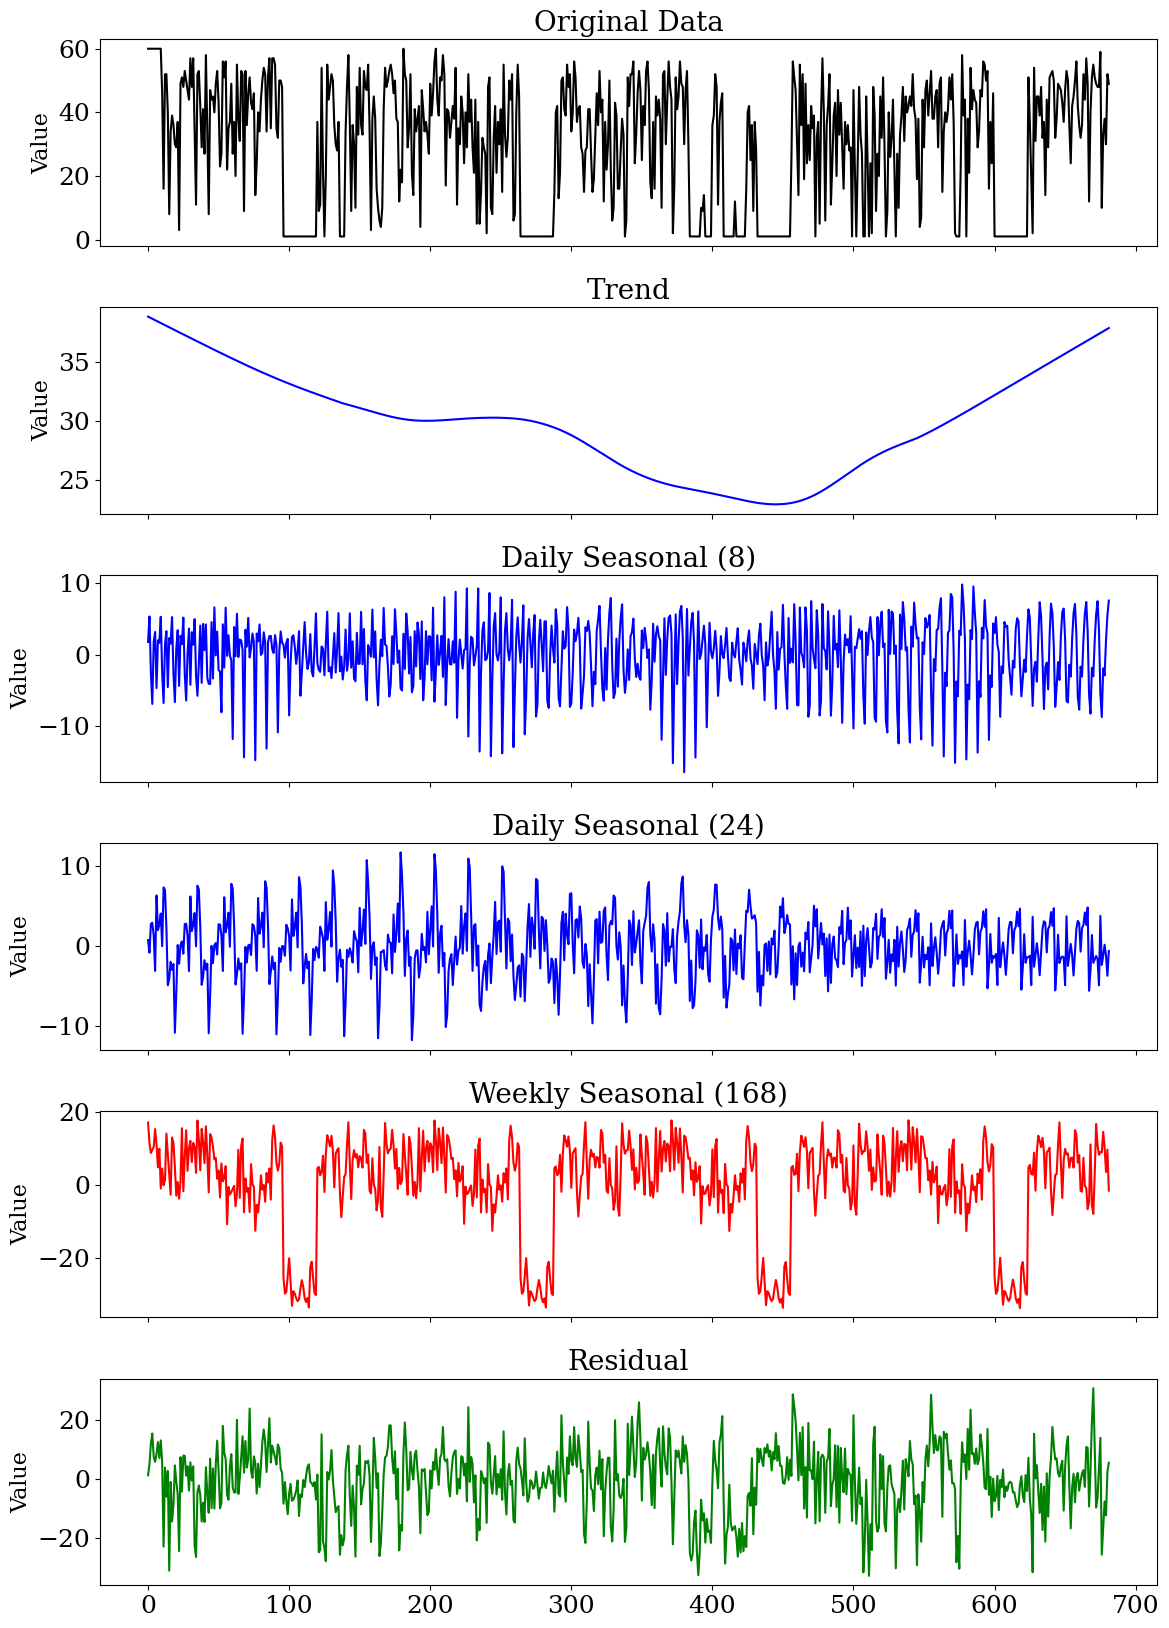

In [5]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt

# Ensure the data is sorted by time
data = data.sort_index()

# MSTL decomposition
stl_kwargs = {"seasonal_deg": 0}
model = MSTL(data['Operation'], periods=(8, 24, 168), stl_kwargs=stl_kwargs)
res = model.fit()

# Extracting the seasonal components
seasonal_8=res.seasonal.iloc[:, 0]
seasonal_24 = res.seasonal.iloc[:, 1]  # Daily seasonal component
seasonal_168 = res.seasonal.iloc[:, 2]  # Weekly seasonal component
trend = res.trend
residual = res.resid

# Plotting
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)

data['Operation'].plot(ax=axes[0], color='black', title='Original Data')
axes[0].set_ylabel('Value')


trend.plot(ax=axes[1], color='blue', title='Trend')
axes[1].set_ylabel('Value')


seasonal_8.plot(ax=axes[2], color='blue', title='Daily Seasonal (8)')
axes[2].set_ylabel('Value')


seasonal_24.plot(ax=axes[3], color='blue', title='Daily Seasonal (24)')
axes[3].set_ylabel('Value')


seasonal_168.plot(ax=axes[4], color='red', title='Weekly Seasonal (168)')
axes[4].set_ylabel('Value')


residual.plot(ax=axes[5], color='green', title='Residual')
axes[5].set_ylabel('Value')

# Save the figure as an SVG file
plt.savefig("d_H1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
# Create DataFrames for each component
trend_df = pd.DataFrame({'Trend': trend})
seasonal_8_df = pd.DataFrame( {'Seasonal_8': seasonal_8})
seasonal_24_df = pd.DataFrame({ 'Seasonal_24': seasonal_24})
seasonal_168_df = pd.DataFrame({ 'Seasonal_168': seasonal_168})
residual_df = pd.DataFrame({ 'Operation': residual})

In [7]:
# Define the number of test samples
test_size = 4

# Divide each DataFrame into train and test sets
trend_train = trend_df.iloc[:-test_size]
trend_test = trend_df.iloc[-test_size:]

seasonal_8_train = seasonal_8_df.iloc[:-test_size]
seasonal_8_test = seasonal_8_df.iloc[-test_size:]

seasonal_24_train = seasonal_24_df.iloc[:-test_size]
seasonal_24_test = seasonal_24_df.iloc[-test_size:]

seasonal_168_train = seasonal_168_df.iloc[:-test_size]
seasonal_168_test = seasonal_168_df.iloc[-test_size:]

In [8]:
reference=data['Operation'].iloc[-test_size:]

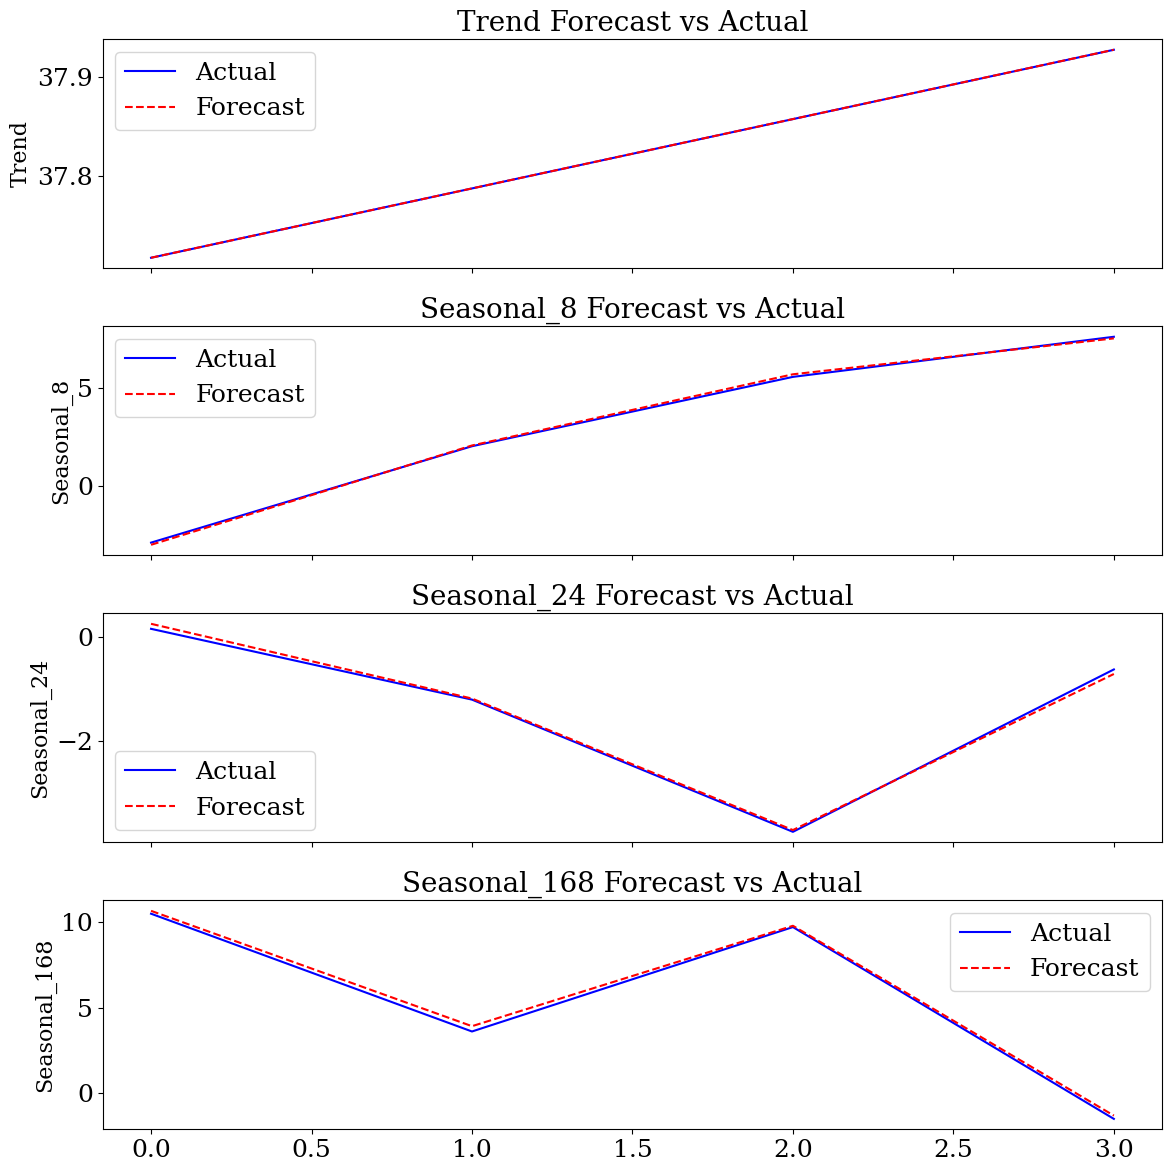

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Initialize dictionaries to store results
mae_results = {}
mape_results = {}


# Define the ETS model (additive trend)
trend_model = ExponentialSmoothing(
    trend_train['Trend'], 
    trend='add',  # Use 'mul' for multiplicative trend if appropriate
    seasonal=None,  # No seasonality for pure trend modeling
    damped_trend=False  # Set to True if a damped trend is preferred
)

# Fit the model
fitted_trend_model = trend_model.fit()

# Forecast the next 20 data points
trend_forecast = np.array(fitted_trend_model.forecast(len(trend_test)))


# Calculate error metrics
mae_results['Trend'] = mean_absolute_error(trend_test['Trend'], trend_forecast)
mape_results['Trend'] = mean_absolute_percentage_error(trend_test['Trend'], trend_forecast)


# Forecast Seasonal (8) by repeating the last period's values
seasonal_8_forecast = np.tile(
    seasonal_8_train['Seasonal_8'][-8:].values,
    len(seasonal_8_test) // 8 + 1
)[:len(seasonal_8_test)]
mae_results['Seasonal_8'] = mean_absolute_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)
mape_results['Seasonal_8'] = mean_absolute_percentage_error(seasonal_8_test['Seasonal_8'], seasonal_8_forecast)

# Forecast Seasonal (24) by repeating the last period's values
seasonal_24_forecast = np.tile(
    seasonal_24_train['Seasonal_24'][-24:].values,
    len(seasonal_24_test) // 24 + 1
)[:len(seasonal_24_test)]
mae_results['Seasonal_24'] = mean_absolute_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)
mape_results['Seasonal_24'] = mean_absolute_percentage_error(seasonal_24_test['Seasonal_24'], seasonal_24_forecast)

# Forecast Seasonal (168) similarly
seasonal_168_forecast = np.tile(
    seasonal_168_train['Seasonal_168'][-168:].values,
    len(seasonal_168_test) // 168 + 1
)[:len(seasonal_168_test)]
mae_results['Seasonal_168'] = mean_absolute_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)
mape_results['Seasonal_168'] = mean_absolute_percentage_error(seasonal_168_test['Seasonal_168'], seasonal_168_forecast)

# Plotting
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
components = ['Trend', 'Seasonal_8','Seasonal_24', 'Seasonal_168']
forecasts = [trend_forecast, seasonal_8_forecast, seasonal_24_forecast, seasonal_168_forecast]
test_data = [trend_test['Trend'],seasonal_8_test['Seasonal_8'], seasonal_24_test['Seasonal_24'], seasonal_168_test['Seasonal_168']]

for i, component in enumerate(components):
    axes[i].plot(test_data[i].values, label="Actual", color='blue')
    axes[i].plot(forecasts[i], label="Forecast", color='red', linestyle='dashed')
    axes[i].set_title(f'{component} Forecast vs Actual')
    axes[i].set_ylabel(component)
    axes[i].legend()

plt.tight_layout()
plt.show()



In [10]:
summed_up_array = np.sum(forecasts, axis=0)

In [11]:
import pandas as pd

# Assuming 'reference_df' is the reference DataFrame with the desired index
# and 'summed_up' is the array with values

summed_up = pd.DataFrame({
    'Index': reference.index,  # Use the index from the reference DataFrame
    'sum': summed_up_array  # Use the values from the array
})

# Set the index to match the reference DataFrame
summed_up.set_index('Index', inplace=True)

# Display the DataFrame
print(summed_up)

             sum
Index           
678    45.645617
679    42.584230
680    49.651840
681    43.407887


In [12]:
reference

678    38
679    30
680    52
681    49
Name: Operation, dtype: int64

In [13]:
file_path = 'summed_up.xlsx'
summed_up.to_excel(file_path, index=False)  # index=False to exclude the index column

In [14]:
file_path = 'reference.xlsx'
reference.to_excel(file_path, index=False)  # index=False to exclude the index column

## PART II FEATURE EXTRACTION

In [15]:
window_length = 24
window_size = 24
time_delay = 8
dimension = 3
stride = 1

In [16]:
df=residual_df

### STATISTICAL FEATURE EXTRACTION by TSFRESH

In [17]:
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import roll_time_series

In [18]:
start_time = time.time()

# Ensure tsfresh is installed
# !pip install tsfresh

# Add an index column to represent time
df['id'] = 1  # All data belongs to one time series
df['time'] = range(len(df))

# Rolling window to create overlapping segments
rolled_df = roll_time_series(df, column_id='id', column_sort='time', max_timeshift=window_size-1)

# Extract features using tsfresh
extracted_features = extract_features(
    rolled_df,
    column_id='id',
    column_sort='time',
    column_value='Operation',
    disable_progressbar=False
)


Feature Extraction: 100%|██████████| 30/30 [00:51<00:00,  1.72s/it]


In [19]:
extracted_features=extracted_features.reset_index(drop=True)

In [20]:
data = extracted_features.iloc[window_length-1:].reset_index(drop=True)

In [21]:
data

,Operation__variance_larger_than_standard_deviation,Operation__has_duplicate_max,Operation__has_duplicate_min,Operation__has_duplicate,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,...,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_3__tau_1,Operation__permutation_entropy__dimension_4__tau_1,Operation__permutation_entropy__dimension_5__tau_1,Operation__permutation_entropy__dimension_6__tau_1,Operation__permutation_entropy__dimension_7__tau_1,Operation__query_similarity_count__query_None__threshold_0.0,Operation__mean_n_absolute_max__number_of_maxima_7
0,1.0,0.0,0.0,0.0,1.240781,3507.665753,12.177839,0.267313,0.637270,4.365955,...,1.458319,1.844621,2.458311,1.783207,2.780466,2.926418,2.944439,2.890372,NaN,19.080239
1,1.0,0.0,0.0,0.0,-4.282574,3522.923057,12.521642,-0.403801,-0.424717,4.365955,...,1.351681,1.925121,2.458311,1.783207,2.780466,2.926418,2.944439,2.890372,NaN,19.080239
2,1.0,0.0,0.0,0.0,-1.383975,3561.149139,12.746425,-0.179018,0.200481,4.365955,...,1.271181,1.711845,2.245035,1.767761,2.846480,2.926418,2.944439,2.890372,NaN,19.080239
3,1.0,0.0,0.0,0.0,-5.582392,3476.665215,12.603647,-0.328839,0.175859,4.365955,...,1.306107,1.884871,2.564949,1.756276,2.846480,2.926418,2.944439,2.890372,NaN,19.080239
4,1.0,0.0,0.0,0.0,-19.857970,3237.186682,12.555539,-0.280730,-0.111963,3.429135,...,1.303876,1.671595,2.564949,1.756276,2.780466,2.926418,2.944439,2.890372,NaN,18.089667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,1.0,0.0,0.0,0.0,12.483634,3415.590143,10.580781,0.019651,-0.103472,1.321189,...,1.438883,1.925121,2.564949,1.540306,2.400563,2.926418,2.944439,2.890372,NaN,19.129352
655,1.0,0.0,0.0,0.0,21.605984,3195.676847,10.354349,-0.206782,0.091554,1.321189,...,1.230932,1.818483,2.564949,1.540306,2.400563,2.926418,2.944439,2.890372,NaN,18.283331
656,1.0,0.0,0.0,0.0,12.128075,3337.378187,10.357825,-0.613909,0.112908,1.321189,...,1.377820,1.732659,2.351673,1.591020,2.400563,2.926418,2.944439,2.890372,NaN,18.500721
657,1.0,0.0,0.0,0.0,12.812365,3340.454401,10.580186,0.451051,0.142798,1.351657,...,1.263626,1.732659,2.458311,1.641735,2.466577,2.926418,2.944439,2.890372,NaN,18.500721


In [22]:
residual_df

,Operation,id,time
0,1.380515,1,0
1,5.144589,1,1
2,12.160610,1,2
3,15.525489,1,3
4,7.706704,1,4
...,...,...,...
677,-16.162745,1,677
678,-7.492370,1,678
679,-12.214303,1,679
680,2.589885,1,680


In [23]:
df_ref = df.iloc[window_length-1:].reset_index(drop=True)

In [24]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)


In [25]:
df_ref = df_ref.drop(index=0).reset_index(drop=True)

In [26]:
regression_target_series = df_ref['Operation']

In [27]:
# Combine features and target into a single dataset for regression analysis
regression_dataset = data.copy()

In [28]:
regression_dataset['Target'] = regression_target_series

In [29]:
df1=regression_dataset

In [30]:
df1 = df1.drop(index=df1.index[-1]).reset_index(drop=True)

In [31]:
df1 = df1.dropna(axis=1, how='all').loc[:, ~(df1 == np.inf).all()]

In [32]:
# Dropping columns with low variance from df1
if 'df1' in locals():
    # Calculate variance of each column
    variance = df1.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    df1 = df1.drop(columns=low_variance_columns)

In [33]:
df1

,Operation__sum_values,Operation__abs_energy,Operation__mean_abs_change,Operation__mean_change,Operation__mean_second_derivative_central,Operation__median,Operation__mean,Operation__standard_deviation,Operation__variation_coefficient,Operation__variance,...,Operation__count_above__t_0,Operation__count_below__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Operation__mean_n_absolute_max__number_of_maxima_7,Target
0,1.240781,3507.665753,12.177839,0.267313,0.637270,4.365955,0.051699,12.089254,233.838277,146.150067,...,0.625000,0.375000,0.429323,0.983961,1.458319,1.844621,2.458311,2.780466,19.080239,-4.142840
1,-4.282574,3522.923057,12.521642,-0.403801,-0.424717,4.365955,-0.178441,12.114315,-67.889906,146.756620,...,0.583333,0.416667,0.617242,0.983961,1.351681,1.925121,2.458311,2.780466,19.080239,8.043188
2,-1.383975,3561.149139,12.746425,-0.179018,0.200481,4.365955,-0.057666,12.181046,-211.235872,148.377889,...,0.583333,0.416667,0.617242,0.983961,1.271181,1.711845,2.245035,2.846480,19.080239,7.962193
3,-5.582392,3476.665215,12.603647,-0.328839,0.175859,4.365955,-0.232600,12.033576,-51.735138,144.806948,...,0.583333,0.416667,0.617242,0.925129,1.306107,1.884871,2.564949,2.846480,19.080239,1.249911
4,-19.857970,3237.186682,12.555539,-0.280730,-0.111963,3.429135,-0.827415,11.584393,-14.000697,134.198162,...,0.583333,0.416667,0.617242,0.925129,1.303876,1.671595,2.564949,2.780466,18.089667,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,26.431435,3159.261803,10.801400,-1.011885,-0.571302,1.321189,1.101310,11.420290,10.369734,130.423025,...,0.541667,0.458333,0.617242,0.858741,1.438883,1.991509,2.564949,2.375647,18.347899,-16.162745
654,12.483634,3415.590143,10.580781,0.019651,-0.103472,1.321189,0.520151,11.918293,22.913121,142.045698,...,0.541667,0.458333,0.617242,0.858741,1.438883,1.925121,2.564949,2.400563,19.129352,-7.492370
655,21.605984,3195.676847,10.354349,-0.206782,0.091554,1.321189,0.900249,11.504032,12.778718,132.342753,...,0.541667,0.458333,0.617242,0.925129,1.230932,1.818483,2.564949,2.400563,18.283331,-12.214303
656,12.128075,3337.378187,10.357825,-0.613909,0.112908,1.321189,0.505336,11.781429,23.314028,138.802060,...,0.541667,0.458333,0.617242,0.858741,1.377820,1.732659,2.351673,2.400563,18.500721,2.589885


In [34]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [35]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df1.drop(columns=[target_column])  # Extract feature columns
y = df1[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.9,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df1 = pd.concat([X_selected, y], axis=1)

In [36]:
end_time = time.time()
statistical_ext=start_time-end_time

In [37]:
file_path = 'statistical_data.xlsx'
df1.to_excel(file_path, index=False)  # index=False to exclude the index column

### TOPOLOGICAL FEATURE EXTRACTION

In [38]:
import pandas as pd
import numpy as np
from gtda.diagrams import (
    Scaler, PersistenceEntropy, Amplitude, BettiCurve, 
    PersistenceLandscape, Silhouette, HeatKernel
)
import gtda.time_series as ts
import gtda.diagrams as diag
from gtda.time_series import TakensEmbedding
from gtda.time_series import SlidingWindow
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from gtda.pipeline import Pipeline
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_point_cloud

In [39]:
start_time = time.time()

In [40]:
X=df['Operation']

In [41]:
import numpy as np
import pandas as pd
from gtda.time_series import SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler

# Load your data (replace 'df' with your actual DataFrame)
X = df['Operation'].to_numpy()

# Sliding Window
SW = SlidingWindow(size=window_size, stride=stride)
X_sw = SW.fit_transform(X)

# Debugging shape
print(f"Sliding Window Output Shape: {X_sw.shape}")

# Takens Embedding
TE = TakensEmbedding(time_delay=time_delay, dimension=dimension)
X_te = TE.fit_transform(X_sw)

# Debugging shape
print(f"Takens Embedding Output Shape: {X_te.shape}")

# Vietoris-Rips Persistence
VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
diagrams = VR.fit_transform(X_te)

# Debugging number of diagrams
print(f"Number of Persistence Diagrams: {len(diagrams)}")

# Scaling Persistence Diagrams
scaler = Scaler()
scaled_diagrams = scaler.fit_transform(diagrams)

# Debugging scaled diagrams shape
print(f"Scaled Diagrams Shape: {scaled_diagrams.shape}")


Sliding Window Output Shape: (659, 24)
Takens Embedding Output Shape: (659, 8, 3)
Number of Persistence Diagrams: 659
Scaled Diagrams Shape: (659, 9, 3)


In [42]:
# Initialize feature extractors
persistence_entropy = PersistenceEntropy()
amplitude_bottleneck = Amplitude(metric='bottleneck')
amplitude_wasserstein = Amplitude(metric='wasserstein')
amplitude_landscape = Amplitude(metric='landscape')
betti_curve = BettiCurve()
persistence_landscape = PersistenceLandscape()
silhouette = Silhouette()
heat_kernel = HeatKernel(sigma=0.1, n_bins=100, n_jobs=-1)

In [43]:
# Extract features
entropy_features = persistence_entropy.fit_transform(scaled_diagrams)
amplitude_bottleneck_features = amplitude_bottleneck.fit_transform(scaled_diagrams)
amplitude_wasserstein_features = amplitude_wasserstein.fit_transform(scaled_diagrams)
amplitude_landscape_features = amplitude_landscape.fit_transform(scaled_diagrams)
betti_features = betti_curve.fit_transform(scaled_diagrams)
landscape_features = persistence_landscape.fit_transform(scaled_diagrams)
silhouette_features = silhouette.fit_transform(scaled_diagrams)
heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

In [44]:
betti_features.shape

(659, 2, 100)

In [45]:
l1_h0 = []
l2_h0 = []
l1_h1 = []
l2_h1 = []

for i in range(betti_features.shape[0]):
    h0_curve = betti_features[i, 0, :]
    h1_curve = betti_features[i, 1, :]

    l1_h0.append(np.sum(np.abs(h0_curve)))
    l2_h0.append(np.sqrt(np.sum(h0_curve**2)))

    l1_h1.append(np.sum(np.abs(h1_curve)))
    l2_h1.append(np.sqrt(np.sum(h1_curve**2)))

# Create DataFrame
betti_df = pd.DataFrame({
    'betti_L1_H0': l1_h0,
    'betti_L2_H0': l2_h0,
    'betti_L1_H1': l1_h1,
    'betti_L2_H1': l2_h1
})

# Show result
betti_df


,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1
0,231,36.180105,0,0.00000
1,213,33.481338,0,0.00000
2,200,33.075671,0,0.00000
3,201,32.908965,0,0.00000
4,278,36.660606,0,0.00000
...,...,...,...,...
654,305,42.836900,6,2.44949
655,277,42.059482,6,2.44949
656,280,41.496988,0,0.00000
657,273,41.243181,0,0.00000


In [46]:
l1_h0_ls = []
l2_h0_ls = []
l1_h1_ls = []
l2_h1_ls = []

for i in range(landscape_features.shape[0]):
    h0_landscape = landscape_features[i, 0, :]
    h1_landscape = landscape_features[i, 1, :]

    l1_h0_ls.append(np.sum(np.abs(h0_landscape)))
    l2_h0_ls.append(np.sqrt(np.sum(h0_landscape**2)))

    l1_h1_ls.append(np.sum(np.abs(h1_landscape)))
    l2_h1_ls.append(np.sqrt(np.sum(h1_landscape**2)))

# Create DataFrame
landscape_df = pd.DataFrame({
    'landscape_features_L1_H0_LS': l1_h0_ls,
    'landscape_features_L2_H0_LS': l2_h0_ls,
    'landscape_features_L1_H1_LS': l1_h1_ls,
    'landscape_features_L2_H1_LS': l2_h1_ls
})

# Show result
landscape_df


,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,landscape_features_L1_H1_LS,landscape_features_L2_H1_LS
0,17.339680,2.615684,0.000000,0.000000
1,17.339680,2.615684,0.000000,0.000000
2,10.805058,1.834850,0.000000,0.000000
3,15.414591,2.394716,0.000000,0.000000
4,34.142720,4.348158,0.000000,0.000000
...,...,...,...,...
654,22.604081,3.191213,0.137897,0.066982
655,11.684410,1.946005,0.137897,0.066982
656,18.559906,2.752552,0.000000,0.000000
657,15.396383,2.392605,0.000000,0.000000


In [47]:
l1_h0_si = []
l2_h0_si = []
l1_h1_si = []
l2_h1_si = []

for i in range(silhouette_features.shape[0]):
    h0_silhouette = silhouette_features[i, 0, :]
    h1_silhouette = silhouette_features[i, 1, :]

    l1_h0_si.append(np.sum(np.abs(h0_silhouette)))
    l2_h0_si.append(np.sqrt(np.sum(h0_silhouette**2)))

    l1_h1_si.append(np.sum(np.abs(h1_silhouette)))
    l2_h1_si.append(np.sqrt(np.sum(h1_silhouette**2)))

# Create DataFrame
silhouette_df = pd.DataFrame({
    'silhouette_features_L1_H0_SI': l1_h0_si,
    'silhouette_features_L2_H0_SI': l2_h0_si,
    'silhouette_features_L1_H1_SI': l1_h1_si,
    'silhouette_features_L2_H1_SI': l2_h1_si
})

# Show result
silhouette_df.head()


,silhouette_features_L1_H0_SI,silhouette_features_L2_H0_SI,silhouette_features_L1_H1_SI,silhouette_features_L2_H1_SI
0,7.945403,1.217724,0.0,0.0
1,8.022068,1.212031,0.0,0.0
2,6.175045,1.039707,0.0,0.0
3,6.903596,1.068815,0.0,0.0
4,16.303287,2.075239,0.0,0.0


In [48]:
# Flatten entropy features
entropy_flattened = entropy_features.reshape(entropy_features.shape[0], -1)
entropy_df = pd.DataFrame(entropy_flattened, columns=[f"entropy_{i}" for i in range(entropy_flattened.shape[1])])

In [49]:
entropy_df

,entropy_0,entropy_1
0,2.714701,-1.0
1,2.654821,-1.0
2,2.684554,-1.0
3,2.668713,-1.0
4,2.578495,-1.0
...,...,...
654,2.759673,0.0
655,2.790061,0.0
656,2.767722,-1.0
657,2.776578,-1.0


In [50]:
# Flatten amplitude bottleneck features
amplitude_bottleneck_flattened = amplitude_bottleneck_features.reshape(amplitude_bottleneck_features.shape[0], -1)
amplitude_bottleneck_df = pd.DataFrame(amplitude_bottleneck_flattened, columns=[f"amplitude_bottleneck_{i}" for i in range(amplitude_bottleneck_flattened.shape[1])])
amplitude_bottleneck_df 

,amplitude_bottleneck_0,amplitude_bottleneck_1
0,0.591889,0.000000
1,0.591889,0.000000
2,0.467216,0.000000
3,0.558089,0.000000
4,0.830516,0.000000
...,...,...
654,0.675819,0.050201
655,0.485849,0.050201
656,0.612362,0.000000
657,0.557764,0.000000


In [51]:
# Flatten amplitude wasserstein features
amplitude_wasserstein_flattened = amplitude_wasserstein_features.reshape(amplitude_wasserstein_features.shape[0], -1)
amplitude_wasserstein_df = pd.DataFrame(amplitude_wasserstein_flattened, columns=[f"amplitude_wasserstein_{i}" for i in range(amplitude_wasserstein_flattened.shape[1])])
amplitude_wasserstein_df


,amplitude_wasserstein_0,amplitude_wasserstein_1
0,0.930030,0.000000
1,0.886531,0.000000
2,0.809490,0.000000
3,0.825648,0.000000
4,1.204241,0.000000
...,...,...
654,1.193092,0.050201
655,1.057875,0.050201
656,1.089568,0.000000
657,1.052937,0.000000


In [52]:
amplitude_landscape_flattened = amplitude_landscape_features.reshape(amplitude_landscape_features.shape[0], -1)
amplitude_landscape_df = pd.DataFrame(amplitude_landscape_flattened, columns=[f"amplitude_landscape_{i}" for i in range(amplitude_landscape_flattened.shape[1])])
amplitude_landscape_df 

,amplitude_landscape_0,amplitude_landscape_1
0,0.371777,0.000000
1,0.371777,0.000000
2,0.260794,0.000000
3,0.340370,0.000000
4,0.618020,0.000000
...,...,...
654,0.453579,0.009023
655,0.276593,0.009023
656,0.391231,0.000000
657,0.340070,0.000000


In [53]:
heat_kernel_features.shape

(659, 2, 100, 100)

In [54]:
def compute_entropy(matrix):
    p = matrix.flatten()
    p = p[p > 0]  # Avoid log(0)
    p /= p.sum()  # Normalize to probability distribution
    return -np.sum(p * np.log(p))


def extract_heat_kernel_features(heat_kernel_features):
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # for each sample
        features_sample = {}

        for dim, h_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim, :, :]

            features_sample[f"L1_{h_dim}"] = np.sum(np.abs(matrix))
            features_sample[f"L2_{h_dim}"] = np.sqrt(np.sum(matrix ** 2))
            features_sample[f"Max_{h_dim}"] = np.max(matrix)
            features_sample[f"Mean_{h_dim}"] = np.mean(matrix)
            features_sample[f"Std_{h_dim}"] = np.std(matrix)
            features_sample[f"Entropy_{h_dim}"] = compute_entropy(matrix)


        feature_list.append(features_sample)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df


heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)
heat_kernel_df.head()


,L1_H0,L2_H0,Max_H0,Mean_H0,Std_H0,Entropy_H0,L1_H1,L2_H1,Max_H1,Mean_H1,Std_H1,Entropy_H1
0,18495.358549,706.465947,58.502428,1.818989e-16,7.064659,6.171638,0.0,0.0,0.0,0.0,0.0,-0.0
1,18201.199435,635.711668,44.491624,1.818989e-16,6.357117,6.290207,0.0,0.0,0.0,0.0,0.0,-0.0
2,18199.538647,689.242169,54.763021,9.094947e-17,6.892422,6.114473,0.0,0.0,0.0,0.0,0.0,-0.0
3,18200.773051,685.086332,54.834356,0.000000e+00,6.850863,6.176156,0.0,0.0,0.0,0.0,0.0,-0.0
4,18204.922509,523.929989,33.641522,-9.094947e-17,5.239300,6.637117,0.0,0.0,0.0,0.0,0.0,-0.0


In [55]:
# Combine all the DataFrames into a single DataFrame
combined_df = pd.concat([
    entropy_df,
    amplitude_bottleneck_df,
    amplitude_wasserstein_df,
    amplitude_landscape_df,
    betti_df,
    landscape_df,
    silhouette_df,
    heat_kernel_df
], axis=1)


In [56]:
features = {}

for dim in range(3):  # Loop over each homology dimension (0 and 1)
    # Filter the diagrams for a specific dimension
    filtered_diagrams = [diagram[diagram[:, 2] == dim] for diagram in scaled_diagrams]

    # Compute lifetimes (death - birth)
    lifetimes = [diagram[:, 1] - diagram[:, 0] for diagram in filtered_diagrams]
    
    # Compute statistics for lifetimes and other features
    for i, lifetime in enumerate(lifetimes):
        sample_key = f'sample_{i + 1}'  # Using 1-based indexing for sample names
        if sample_key not in features:
            features[sample_key] = {}
        
        features[sample_key][f'dim_{dim}_num_features'] = len(lifetime)
        features[sample_key][f'dim_{dim}_sum_lifetimes'] = np.sum(lifetime)
        if len(lifetime) > 0:
            features[sample_key][f'dim_{dim}_max_lifetime'] = np.max(lifetime)
            features[sample_key][f'dim_{dim}_mean_lifetime'] = np.mean(lifetime)
            features[sample_key][f'dim_{dim}_median_lifetime'] = np.median(lifetime)
            features[sample_key][f'dim_{dim}_std_lifetime'] = np.std(lifetime)
            features[sample_key][f'dim_{dim}_variance_lifetime'] = np.var(lifetime)
            features[sample_key][f'dim_{dim}_min_lifetime'] = np.min(lifetime)
            
            birth_times = filtered_diagrams[i][:, 0]
            death_times = filtered_diagrams[i][:, 1]
            
            features[sample_key][f'dim_{dim}_sum_birth_times'] = np.sum(birth_times)
            features[sample_key][f'dim_{dim}_mean_birth_time'] = np.mean(birth_times)
            features[sample_key][f'dim_{dim}_sum_death_times'] = np.sum(death_times)
            features[sample_key][f'dim_{dim}_mean_death_time'] = np.mean(death_times)
        else:
            features[sample_key][f'dim_{dim}_max_lifetime'] = 0
            features[sample_key][f'dim_{dim}_mean_lifetime'] = 0
            features[sample_key][f'dim_{dim}_median_lifetime'] = 0
            features[sample_key][f'dim_{dim}_std_lifetime'] = 0
            features[sample_key][f'dim_{dim}_variance_lifetime'] = 0
            features[sample_key][f'dim_{dim}_min_lifetime'] = 0
            
            features[sample_key][f'dim_{dim}_sum_birth_times'] = 0
            features[sample_key][f'dim_{dim}_mean_birth_time'] = 0
            features[sample_key][f'dim_{dim}_sum_death_times'] = 0
            features[sample_key][f'dim_{dim}_mean_death_time'] = 0

# Convert the nested dictionary to a DataFrame
features_df = pd.DataFrame.from_dict(features, orient='index')



In [57]:
features_df.reset_index(drop=True, inplace=True)

In [58]:
final_combined_df = pd.concat([combined_df.reset_index(drop=True), features_df], axis=1)

In [59]:
final_combined_df = final_combined_df.loc[:, ~final_combined_df.isin([np.inf, -np.inf]).any() & final_combined_df.notna().all()]

In [60]:
# Dropping columns with low variance from final_combined_df
if 'final_combined_df' in locals():
    # Calculate variance of each column
    variance = final_combined_df.var()
    
    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance
    
    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index
    
    # Drop low variance columns
    final_combined_df_cleaned = final_combined_df.drop(columns=low_variance_columns)

In [61]:
data=final_combined_df_cleaned

In [62]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)

In [63]:
simplified_df=data

In [64]:
# Adjust the indices of the feature dataset for regression analysis
regression_features_df = simplified_df[:-1].reset_index(drop=True)
regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

# Combine features and target into a single dataset for regression analysis
regression_dataset = regression_features_df.copy()
regression_dataset['Target'] = regression_target_series

In [65]:
df2=regression_dataset

In [66]:
df2

,entropy_1,amplitude_bottleneck_0,amplitude_wasserstein_0,amplitude_landscape_0,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,landscape_features_L1_H0_LS,landscape_features_L2_H0_LS,...,dim_0_mean_lifetime,dim_0_median_lifetime,dim_0_min_lifetime,dim_0_sum_death_times,dim_0_mean_death_time,dim_1_sum_birth_times,dim_1_mean_birth_time,dim_1_sum_death_times,dim_1_mean_death_time,Target
0,-1.0,0.591889,0.930030,0.371777,231,36.180105,0,0.00000,17.339680,2.615684,...,0.658262,0.596196,0.386877,4.607837,0.658262,0.449125,0.224562,0.449125,0.224562,-4.142840
1,-1.0,0.591889,0.886531,0.371777,213,33.481338,0,0.00000,17.339680,2.615684,...,0.605448,0.501286,0.285090,4.238138,0.605448,0.449125,0.224562,0.449125,0.224562,8.043188
2,-1.0,0.467216,0.809490,0.260794,200,33.075671,0,0.00000,10.805058,1.834850,...,0.564418,0.501286,0.285090,3.950924,0.564418,0.449125,0.224562,0.449125,0.224562,7.962193
3,-1.0,0.558089,0.825648,0.340370,201,32.908965,0,0.00000,15.414591,2.394716,...,0.567399,0.511818,0.285090,3.971791,0.567399,0.449125,0.224562,0.449125,0.224562,1.249911
4,-1.0,0.830516,1.204241,0.618020,278,36.660606,0,0.00000,34.142720,4.348158,...,0.790339,0.722078,0.285090,5.532375,0.790339,0.449125,0.224562,0.449125,0.224562,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,-1.0,0.500157,1.038013,0.288799,268,40.422766,0,0.00000,12.381603,2.031884,...,0.763503,0.705450,0.551740,5.344522,0.763503,0.449125,0.224562,0.449125,0.224562,-16.162745
654,0.0,0.675819,1.193092,0.453579,305,42.836900,6,2.44949,22.604081,3.191213,...,0.871958,0.820814,0.583203,6.103703,0.871958,1.279177,0.639589,1.379580,0.689790,-7.492370
655,0.0,0.485849,1.057875,0.276593,277,42.059482,6,2.44949,11.684410,1.946005,...,0.790391,0.780672,0.583203,5.532736,0.790391,1.279177,0.639589,1.379580,0.689790,-12.214303
656,-1.0,0.612362,1.089568,0.391231,280,41.496988,0,0.00000,18.559906,2.752552,...,0.800210,0.716350,0.591398,5.601471,0.800210,0.449125,0.224562,0.449125,0.224562,2.589885


In [67]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [68]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df2.drop(columns=[target_column])  # Extract feature columns
y = df2[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.9,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df2 = pd.concat([X_selected, y], axis=1)

In [69]:
end_time = time.time()
topological_ext=start_time-end_time

In [70]:
file_path = 'topological_data.xlsx'
df2.to_excel(file_path, index=False)  # index=False to exclude the index column

### COMBINING FEATURES

In [71]:
print(df1.shape)
print(df2.shape)

(658, 253)
(658, 13)


In [72]:
df1 = df1.reset_index(drop=True)
df2 = df2.reset_index(drop=True)
df1 = df1.drop('Target', axis=1)

In [73]:
df3= pd.concat([df2, df1], axis=1)

In [74]:
df3

,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,silhouette_features_L1_H0_SI,silhouette_features_L1_H1_SI,L1_H0,Std_H0,Entropy_H0,dim_0_median_lifetime,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_0,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_1,Operation__count_above__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Operation__mean_n_absolute_max__number_of_maxima_7
0,231,36.180105,0,0.00000,7.945403,0.000000,18495.358549,7.064659,6.171638,0.596196,...,0.050248,0.095645,0.625000,0.429323,0.983961,1.458319,1.844621,2.458311,2.780466,19.080239
1,213,33.481338,0,0.00000,8.022068,0.000000,18201.199435,6.357117,6.290207,0.501286,...,0.117910,0.047762,0.583333,0.617242,0.983961,1.351681,1.925121,2.458311,2.780466,19.080239
2,200,33.075671,0,0.00000,6.175045,0.000000,18199.538647,6.892422,6.114473,0.501286,...,0.125890,0.075231,0.583333,0.617242,0.983961,1.271181,1.711845,2.245035,2.846480,19.080239
3,201,32.908965,0,0.00000,6.903596,0.000000,18200.773051,6.850863,6.176156,0.511818,...,0.096498,0.082070,0.583333,0.617242,0.925129,1.306107,1.884871,2.564949,2.846480,19.080239
4,278,36.660606,0,0.00000,16.303287,0.000000,18204.922509,5.239300,6.637117,0.722078,...,0.051978,0.119120,0.583333,0.617242,0.925129,1.303876,1.671595,2.564949,2.780466,18.089667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,268,40.422766,0,0.00000,8.445050,0.000000,18533.236958,7.246619,6.026625,0.705450,...,0.091301,0.020501,0.541667,0.617242,0.858741,1.438883,1.991509,2.564949,2.375647,18.347899
654,305,42.836900,6,2.44949,11.541242,0.137897,18533.842489,6.894585,6.201800,0.820814,...,0.084076,0.019291,0.541667,0.617242,0.858741,1.438883,1.925121,2.564949,2.400563,19.129352
655,277,42.059482,6,2.44949,8.274008,0.137897,18533.842424,8.077916,5.850255,0.780672,...,0.022441,0.006277,0.541667,0.617242,0.925129,1.230932,1.818483,2.564949,2.400563,18.283331
656,280,41.496988,0,0.00000,9.478212,0.000000,18533.968890,7.714188,6.020489,0.716350,...,0.019407,0.005953,0.541667,0.617242,0.858741,1.377820,1.732659,2.351673,2.400563,18.500721


In [75]:
file_path = 'combined_data.xlsx'
df3.to_excel(file_path, index=False)  # index=False to exclude the index column

## PART III FEATURE SELECTION and FORECASTING

In [76]:
data_path = 'summed_up.xlsx'
summed_up = pd.read_excel(data_path)

In [77]:
data_path = 'reference.xlsx'
reference = pd.read_excel(data_path)

In [78]:
data_path = 'statistical_data.xlsx'
datas = pd.read_excel(data_path)

In [79]:
data_path = 'topological_data.xlsx'
datat = pd.read_excel(data_path)

In [80]:
data_path = 'combined_data.xlsx'
datac = pd.read_excel(data_path)

In [81]:
from statsmodels.tsa.stattools import kpss

# Applying the KPSS test to the training data to test for stationarity
kpss_test = kpss(datac['Target'], regression='c')

# Unpacking the KPSS test results
kpss_statistic, p_value, lags, critical_values = kpss_test

# Displaying the KPSS test results
kpss_test_result = {
    'KPSS Statistic': kpss_statistic,
    'p-value': p_value,
    'Lags Used': lags,
    'Critical Values': critical_values,
    'Conclusion': 'Stationary' if p_value > 0.05 else 'Not stationary'
}

kpss_test_result


C:\Users\ar600780\AppData\Local\Temp\ipykernel_15160\1226833019.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(datac['Target'], regression='c')


{'KPSS Statistic': 0.035404888573579256,
 'p-value': 0.1,
 'Lags Used': 13,
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739},
 'Conclusion': 'Stationary'}

In [82]:
from pmdarima.arima import auto_arima, OCSBTest, CHTest

# time series after first differencing
# OCSB test that returns the recommended order of seasonal differencing:
n_ocsb = OCSBTest(m=12).estimate_seasonal_differencing_term(datac['Target'])

# CH test that returns the recommended order of seasonal differencing:
n_ch = CHTest(m=12).estimate_seasonal_differencing_term(datac['Target'])

# seasonal differencing recommendation:
print("time series -")
n_seasdiffs = {"recommended order of seasonal differencing":"", "OCSB recommendation":n_ocsb, "nCH recommendation":n_ch}
[print(key, ":", value) for key,value in n_seasdiffs.items()]

time series -
recommended order of seasonal differencing : 
OCSB recommendation : 0
nCH recommendation : 0


[None, None, None]

In [83]:
train_data = datac[:-4]  # Last 4 rows for testing
test_data = datac[-4:]

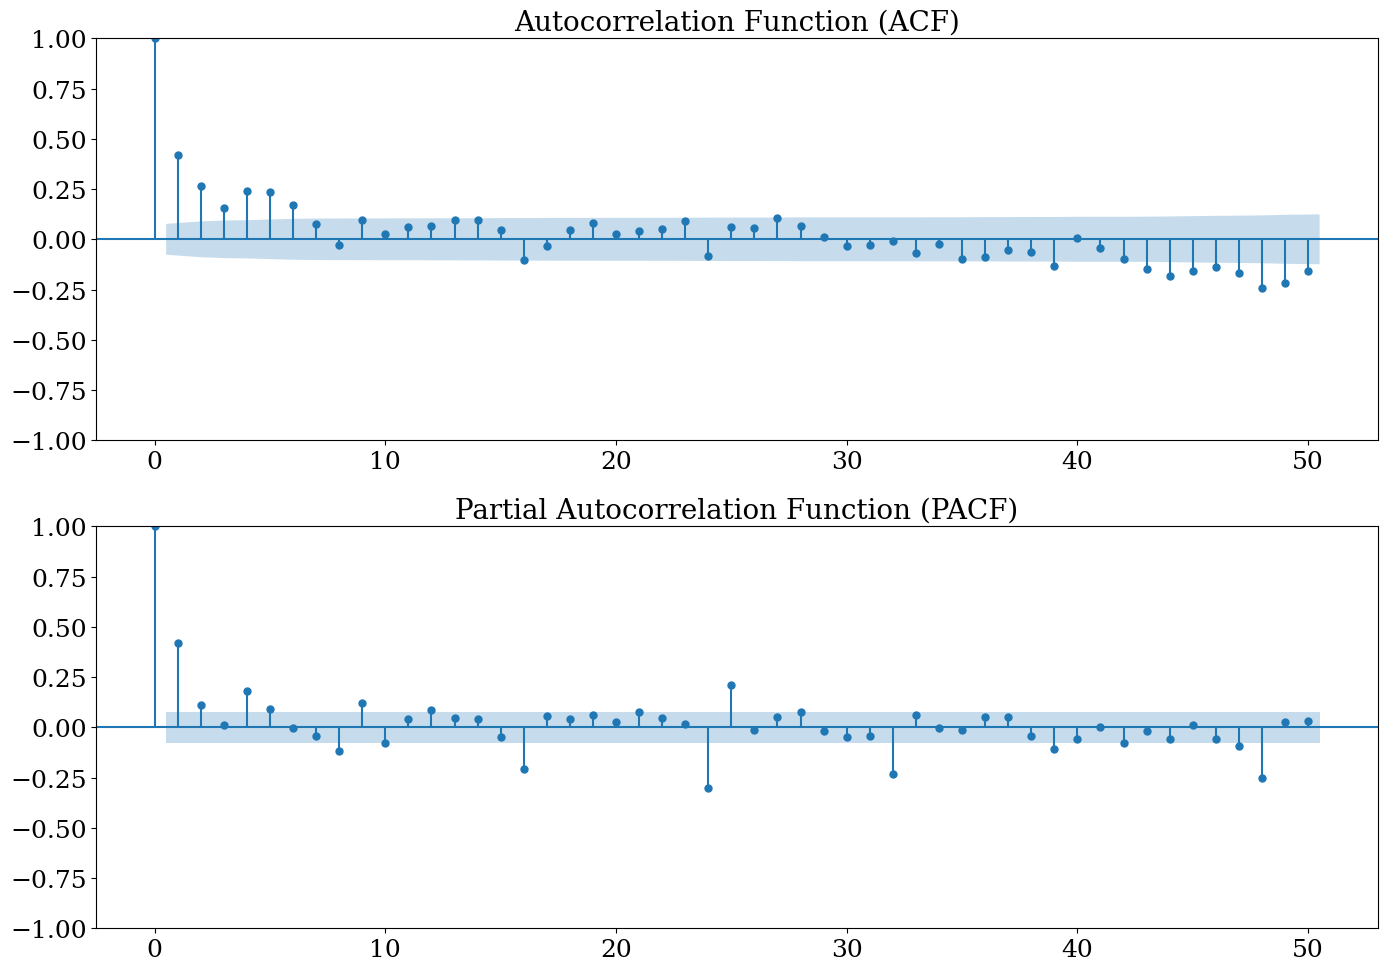

In [84]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the cleaned training data
plt.figure(figsize=(14, 10))

# ACF plot
plt.subplot(2, 1, 1)
plot_acf(train_data['Target'], lags=50, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

# PACF plot
plt.subplot(2, 1, 2)
plot_pacf(train_data['Target'], lags=50, ax=plt.gca(), method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

# Save the figure as an SVG file
plt.savefig("acf_h1.svg", format="svg", dpi=900, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()

# prepare to store results

In [85]:
# Initialize a DataFrame to store results
def initialize_results():
    columns = ['Model_Name', 'MAE', 'MAPE']
    return pd.DataFrame(columns=columns)

# Function to add new results to the DataFrame
def update_results(results_df, model_name, mae, mape):
    new_result = {'Model_Name': model_name, 'MAE': mae, 'MAPE': mape}
    results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
    return results_df
# Example usage
if __name__ == "__main__":
    # Initialize results DataFrame
    main_results = initialize_results()

### TOPOLOGICAL DATASET

In [86]:
main_results = update_results(main_results, 'Topological Dataset','0' ,'0' )

In [87]:
start_time=time.time()

In [88]:
data=datat

In [89]:
data

,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,silhouette_features_L1_H0_SI,silhouette_features_L1_H1_SI,L1_H0,Std_H0,Entropy_H0,dim_0_median_lifetime,dim_0_min_lifetime,dim_1_sum_death_times,Target
0,231,36.180105,0,0.00000,7.945403,0.000000,18495.358549,7.064659,6.171638,0.596196,0.386877,0.449125,-4.142840
1,213,33.481338,0,0.00000,8.022068,0.000000,18201.199435,6.357117,6.290207,0.501286,0.285090,0.449125,8.043188
2,200,33.075671,0,0.00000,6.175045,0.000000,18199.538647,6.892422,6.114473,0.501286,0.285090,0.449125,7.962193
3,201,32.908965,0,0.00000,6.903596,0.000000,18200.773051,6.850863,6.176156,0.511818,0.285090,0.449125,1.249911
4,278,36.660606,0,0.00000,16.303287,0.000000,18204.922509,5.239300,6.637117,0.722078,0.285090,0.449125,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,268,40.422766,0,0.00000,8.445050,0.000000,18533.236958,7.246619,6.026625,0.705450,0.551740,0.449125,-16.162745
654,305,42.836900,6,2.44949,11.541242,0.137897,18533.842489,6.894585,6.201800,0.820814,0.583203,1.379580,-7.492370
655,277,42.059482,6,2.44949,8.274008,0.137897,18533.842424,8.077916,5.850255,0.780672,0.583203,1.379580,-12.214303
656,280,41.496988,0,0.00000,9.478212,0.000000,18533.968890,7.714188,6.020489,0.716350,0.591398,0.449125,2.589885


### RFE by P-VALUE

In [90]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
df = data 

# Identify target column (y) - Update if needed!
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training (first 645 rows) and testing (last 4 rows)
train_df = df.iloc[:-4]  # First 645 rows


X_train = train_df[exog_columns]
y_train = train_df[target_column]

# Define SARIMAX model function to get p-values
def get_p_values(X, y):
    """
    Fit a SARIMAX model and return p-values of the exogenous variables.
    """
    model = SARIMAX(y, 
                    order=(2, 0, 0),  
                    seasonal_order=(1, 0, 1, 8),  
                    exog=X)  
    result = model.fit(disp=False)
    
    # Extract p-values for exogenous variables
    p_values = result.pvalues.loc[X.columns]
    return p_values

# RFE Process (Removing 5 Features Per Step Only if p > 0.05)
step = 20  
step2= 5
selected_features = exog_columns.copy()
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Filter out only features with p-value > 0.05
    worst_candidates = p_values[p_values > 0.05]
    
    # **STOPPING CRITERIA**: If fewer than 5 features have p > 0.05, stop the algorithm
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Select the worst 5 features based on p-value
    worst_features = worst_candidates.sort_values(ascending=False).index[:step]  

    # Remove worst features
    for feature in worst_features:
        selected_features.remove(feature)
        print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

# Final Selected Features
print("Final Selected Features:", selected_features)


Removed Feature: betti_L1_H0, p-value: 0.9637116758464764
Removed Feature: silhouette_features_L1_H0_SI, p-value: 0.944134596130467
Removed Feature: betti_L2_H0, p-value: 0.8494010005809303
Removed Feature: dim_1_sum_death_times, p-value: 0.7395054102076961
Removed Feature: Std_H0, p-value: 0.6302104614294992
Removed Feature: dim_0_min_lifetime, p-value: 0.5586362461080119
Removed Feature: L1_H0, p-value: 0.4840228290240076
Removed Feature: Entropy_H0, p-value: 0.33101901750149676
Removed Feature: silhouette_features_L1_H1_SI, p-value: 0.2371667052834474
Removed Feature: betti_L2_H1, p-value: 0.16406288926897872
Removed Feature: betti_L1_H1, p-value: 0.14217746379830515
Stopping early: Only 0 features have p > 0.05.
Final Selected Features: ['dim_0_median_lifetime']


In [91]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = data[columns_to_keep]


In [92]:
data_rfe

,dim_0_median_lifetime,Target
0,0.596196,-4.142840
1,0.501286,8.043188
2,0.501286,7.962193
3,0.511818,1.249911
4,0.722078,4.444332
...,...,...
653,0.705450,-16.162745
654,0.820814,-7.492370
655,0.780672,-12.214303
656,0.716350,2.589885


### PSO by BIC

In [93]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(2, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=300, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(2, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 300

PSO Runs Results:
   Run          BIC        Selected Features
0    1  4700.414498  [dim_0_median_lifetime]
1    2  4700.414498  [dim_0_median_lifetime]
2    3  4700.414498  [dim_0_median_lifetime]
3    4  4700.414498  [dim_0_median_lifetime]
4    5  4700.414498  [dim_0_median_lifetime]

Best Run Summary:
Run                                        1
BIC                              4700.414498
Selected Features    [dim_0_median_lifetime]
Name: 0, dtype: object

Final Feature Selection (Chosen in at least 3 runs or from best run if empty):
['dim_0_median

In [94]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [95]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [96]:
data_pso=data_rfe[selected_features_pso]

In [97]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [98]:
data_pso_best=data_rfe[selected_features_pso]

In [99]:
data_pso_best

,dim_0_median_lifetime,Target
0,0.596196,-4.142840
1,0.501286,8.043188
2,0.501286,7.962193
3,0.511818,1.249911
4,0.722078,4.444332
...,...,...
653,0.705450,-16.162745
654,0.820814,-7.492370
655,0.780672,-12.214303
656,0.716350,2.589885


In [100]:
data_pso

,dim_0_median_lifetime,Target
0,0.596196,-4.142840
1,0.501286,8.043188
2,0.501286,7.962193
3,0.511818,1.249911
4,0.722078,4.444332
...,...,...
653,0.705450,-16.162745
654,0.820814,-7.492370
655,0.780672,-12.214303
656,0.716350,2.589885


In [101]:
data_rfe

,dim_0_median_lifetime,Target
0,0.596196,-4.142840
1,0.501286,8.043188
2,0.501286,7.962193
3,0.511818,1.249911
4,0.722078,4.444332
...,...,...
653,0.705450,-16.162745
654,0.820814,-7.492370
655,0.780672,-12.214303
656,0.716350,2.589885


In [102]:
end_time=time.time()

In [103]:
topological_elim=end_time-start_time

# no feature sarima

In [104]:
start_time=time.time()

In [105]:
train_data = data[:-4]  # Last 4 rows for testing
test_data = data[-4:]

                                      SARIMAX Results                                      
Dep. Variable:                              Target   No. Observations:                  654
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 8)   Log Likelihood               -2365.279
Date:                             Mon, 24 Mar 2025   AIC                           4740.558
Time:                                     09:27:14   BIC                           4762.973
Sample:                                          0   HQIC                          4749.250
                                             - 654                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5065      0.036     13.990      0.000       0.436       0.578
ar.L2          0.2323      

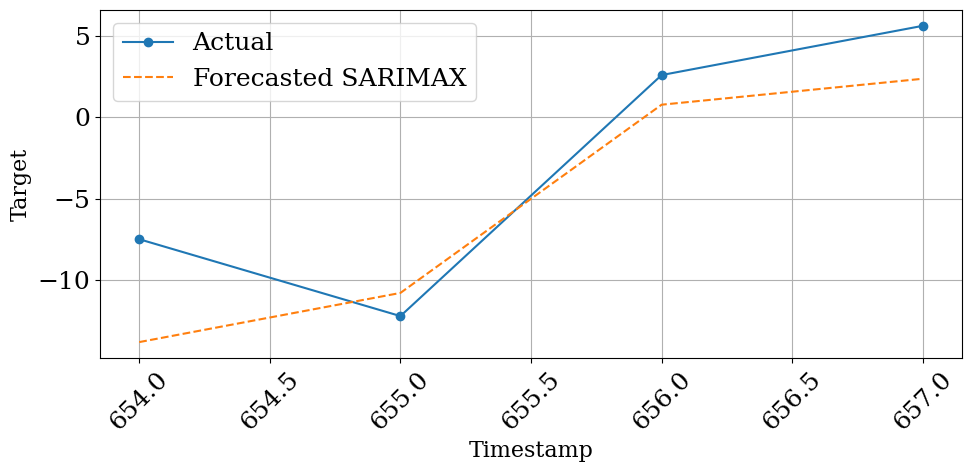

MAE: 3.20, MAPE: 0.56


In [106]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Ensure data is sorted
train_data = train_data.sort_index()
test_data = test_data.sort_index()

# Fit SARIMAX model with combined Fourier terms
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)
print(sarimax_results.summary())
# Forecast using combined Fourier terms
sarimax_forecast = sarimax_results.get_forecast(steps=len(test_data)).predicted_mean


# Evaluation metrics
sarimax_mae = mean_absolute_error(test_data['Target'], sarimax_forecast)
sarimax_mape = mean_absolute_percentage_error(test_data['Target'], sarimax_forecast)


# Plot results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarimax_forecast, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print evaluation metrics
print(f"MAE: {sarimax_mae:.2f}, MAPE: {sarimax_mape:.2f}")


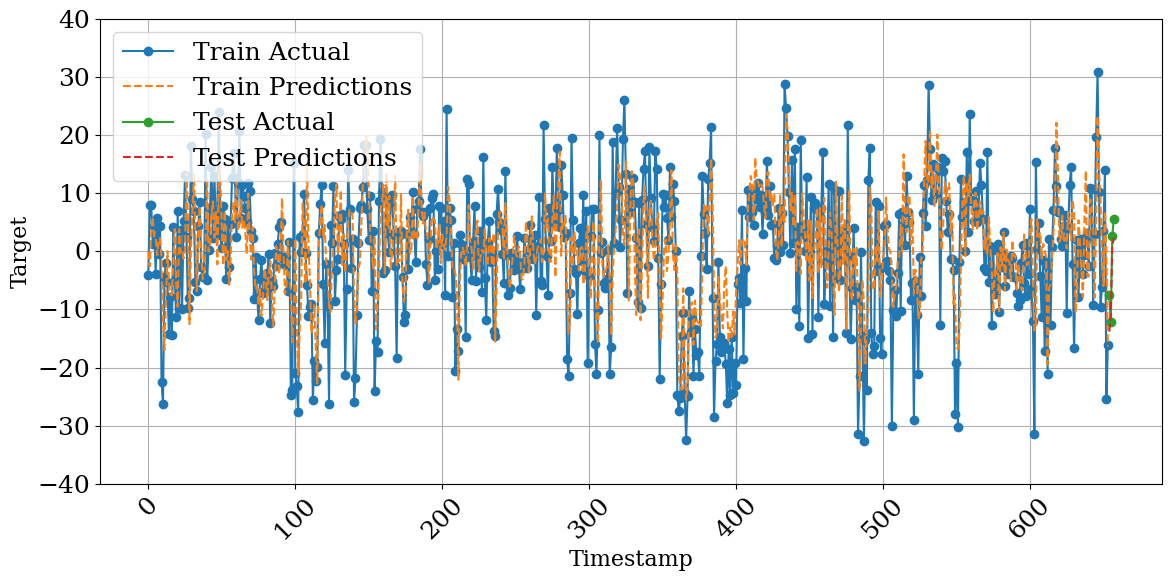

Train MAE: 7.0353
Train MAPE: 3.4421
Test MAE: 3.2032
Test MAPE: 0.5604


In [107]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0),  # AR(4) with no differencing
                seasonal_order=(1, 0, 1, 8)
                )  
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                      )

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data))
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     31.834331
1     31.792303
2     50.421422
3     45.771778
MAE: 3.19
MAPE: 7.96%


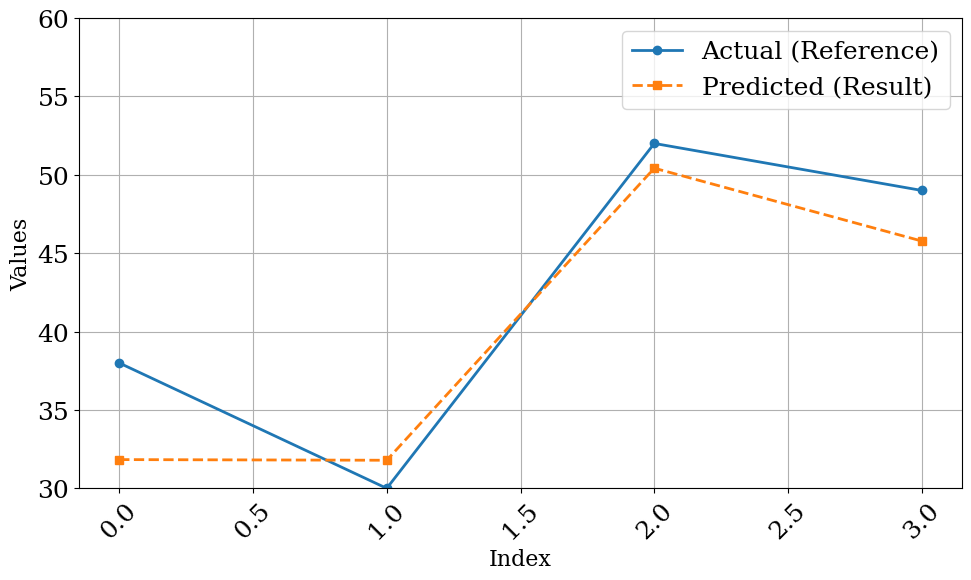

In [108]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarimax_forecast.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA W NO FEATURE', mae, mape)

In [109]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559


#### rfe dataset

In [110]:
train_data = data_rfe[:-4]  # Last 4 rows for testing
test_data = data_rfe[-4:]

In [111]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [112]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

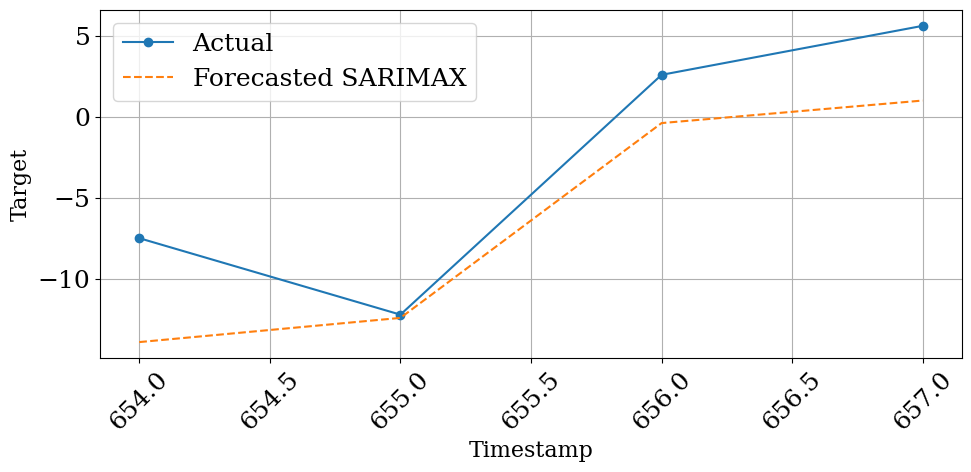

(3.551369260294254, 0.710972610623557)

In [113]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


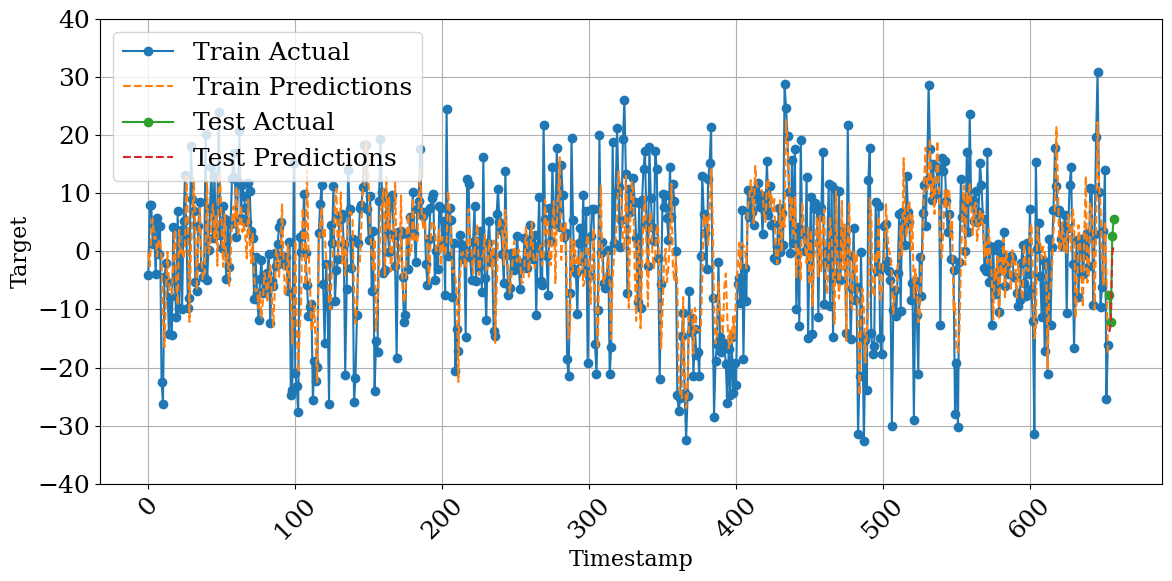

Train MAE: 6.9726
Train MAPE: 3.3066
Test MAE: 3.5514
Test MAPE: 0.7110


In [114]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     31.738109
1     30.169753
2     49.263483
3     44.411166
MAE: 3.44
MAPE: 7.92%


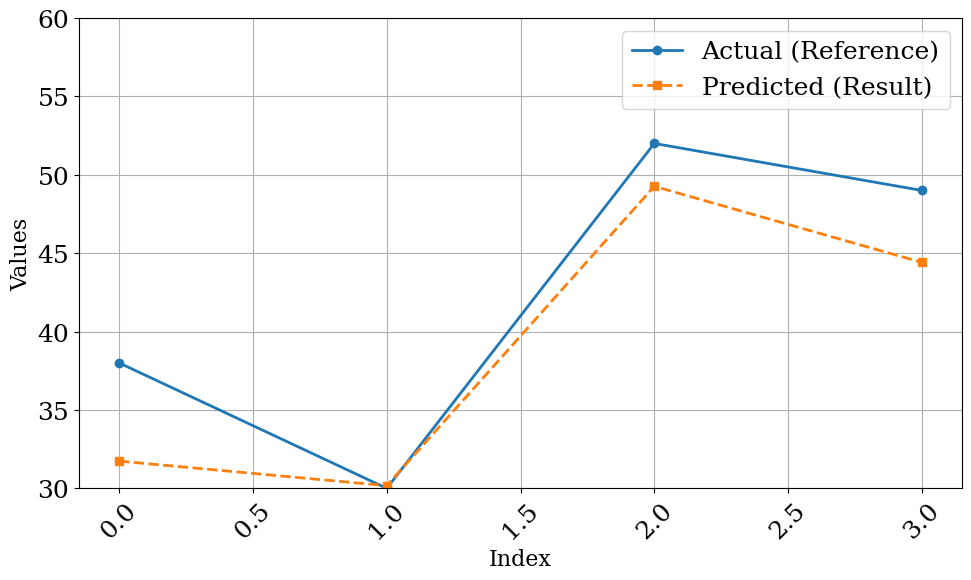

In [115]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w RFE', mae, mape)

In [116]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918


#### pso dataset

In [117]:
train_data = data_pso[:-4]  # Last 4 rows for testing
test_data = data_pso[-4:]

In [118]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [119]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

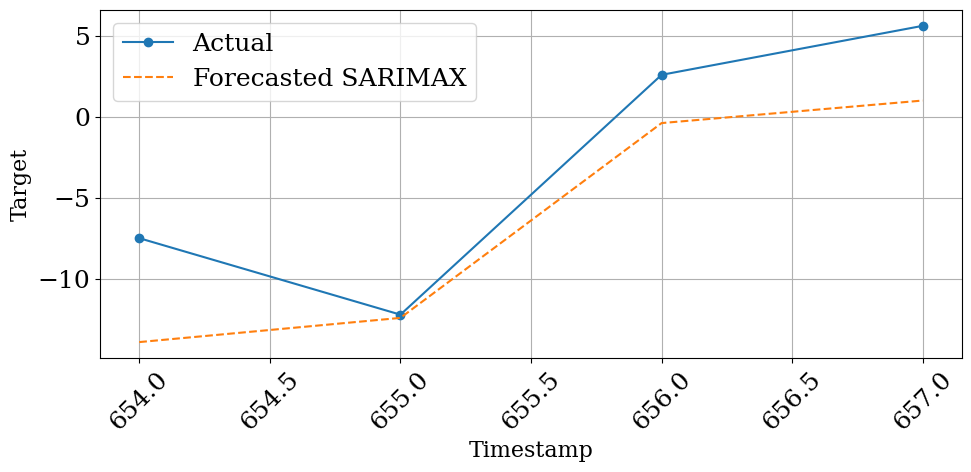

(3.551369260294254, 0.710972610623557)

In [120]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


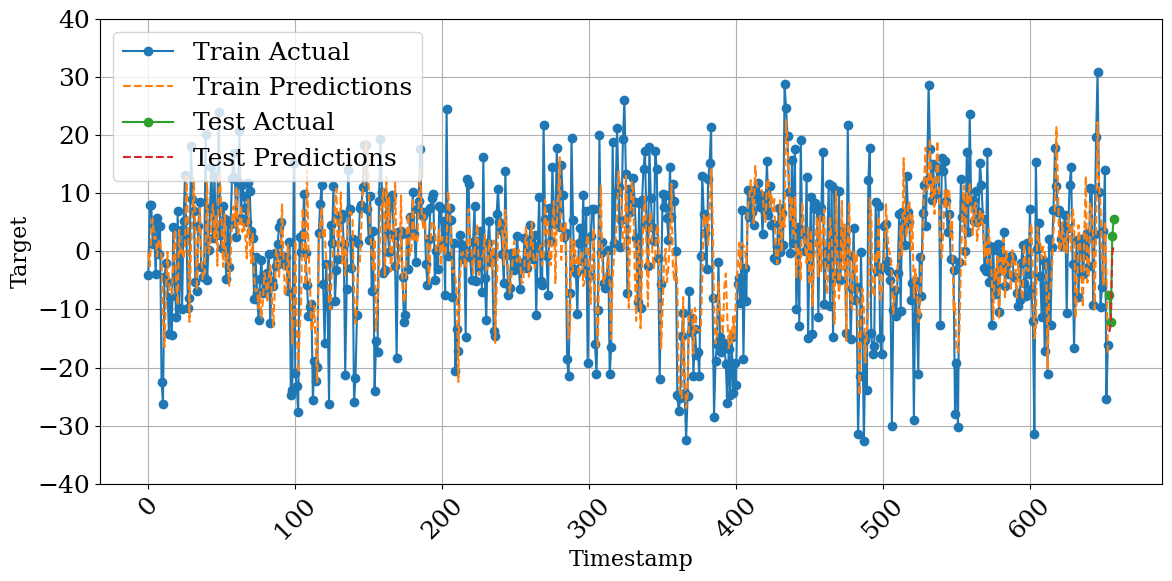

Train MAE: 6.9726
Train MAPE: 3.3066
Test MAE: 3.5514
Test MAPE: 0.7110


In [121]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     31.738109
1     30.169753
2     49.263483
3     44.411166
MAE: 3.44
MAPE: 7.92%


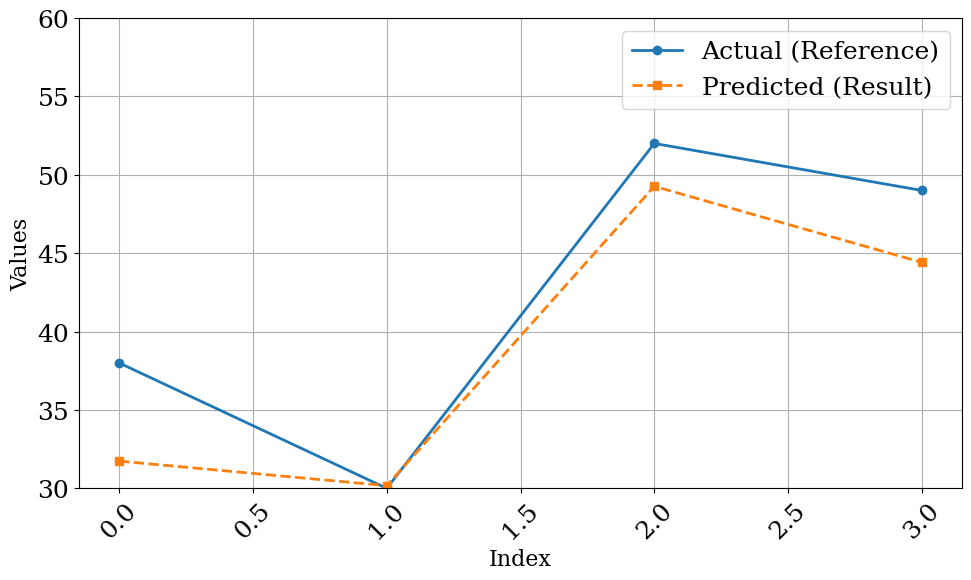

In [122]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w PSO', mae, mape)

In [123]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918


#### pso_best dataset

In [124]:
train_data = data_pso_best[:-4]  # Last 4 rows for testing
test_data = data_pso_best[-4:]

In [125]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [126]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

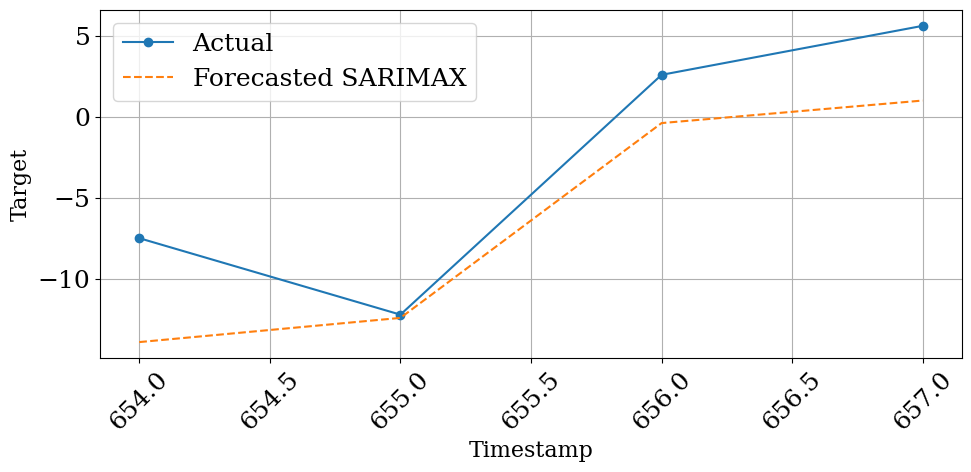

(3.551369260294254, 0.710972610623557)

In [127]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


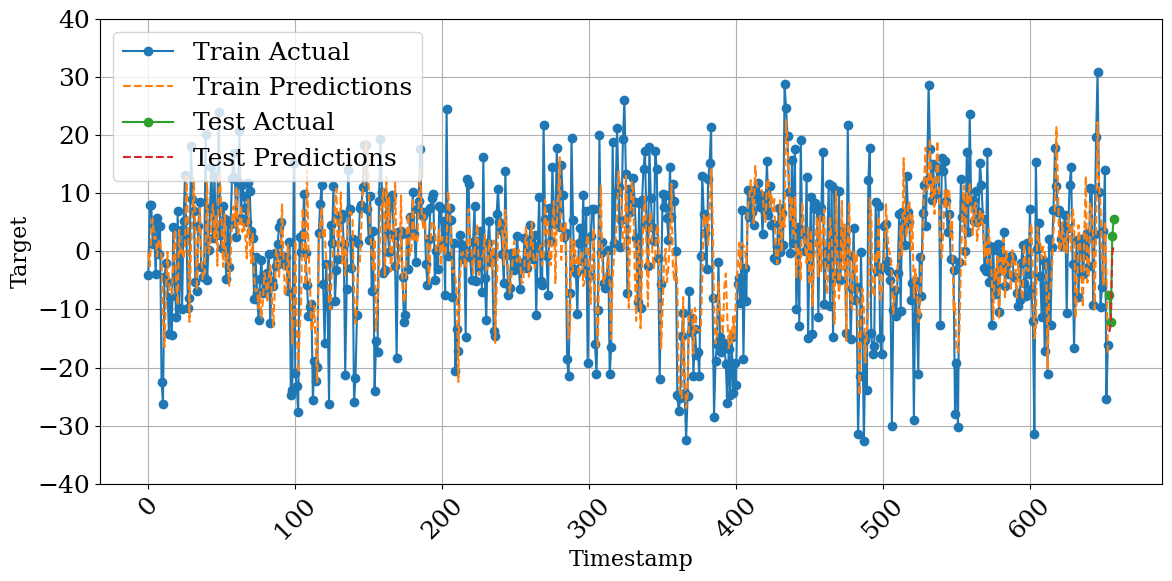

Train MAE: 6.9726
Train MAPE: 3.3066
Test MAE: 3.5514
Test MAPE: 0.7110


In [128]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     31.738109
1     30.169753
2     49.263483
3     44.411166
MAE: 3.44
MAPE: 7.92%


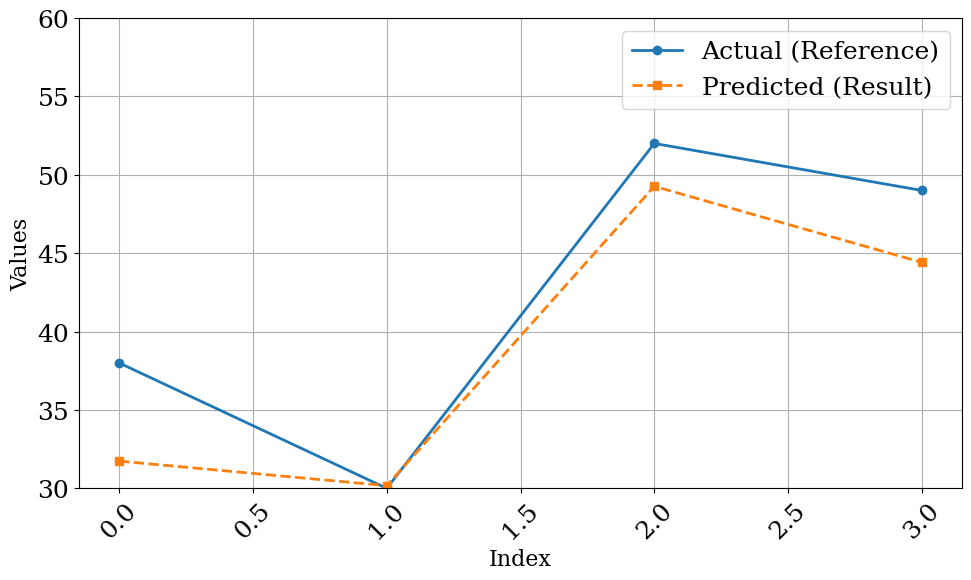

In [129]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w PSO Best', mae, mape)

In [130]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918
4,SARIMA w PSO Best,3.439248,0.07918


In [131]:
end_time=time.time()

In [132]:
topological_modelling= end_time-start_time

### STATISTICAL DATASET

In [133]:
main_results = update_results(main_results, 'Statistical Dataset','0' ,'0' )

In [134]:
start_time=time.time()

In [135]:
data=datas

In [136]:
data

,Operation__mean_second_derivative_central,Operation__standard_deviation,Operation__variation_coefficient,Operation__skewness,Operation__kurtosis,Operation__longest_strike_below_mean,Operation__longest_strike_above_mean,Operation__count_above_mean,Operation__last_location_of_maximum,Operation__last_location_of_minimum,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_1,Operation__count_above__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Operation__mean_n_absolute_max__number_of_maxima_7,Target
0,0.637270,12.089254,233.838277,-1.198499,0.795979,4,11,15,0.166667,0.666667,...,0.095645,0.625000,0.429323,0.983961,1.458319,1.844621,2.458311,2.780466,19.080239,-4.142840
1,-0.424717,12.114315,-67.889906,-1.132111,0.658861,4,10,14,0.125000,0.625000,...,0.047762,0.583333,0.617242,0.983961,1.351681,1.925121,2.458311,2.780466,19.080239,8.043188
2,0.200481,12.181046,-211.235872,-1.135405,0.630500,4,9,14,0.083333,0.583333,...,0.075231,0.583333,0.617242,0.983961,1.271181,1.711845,2.245035,2.846480,19.080239,7.962193
3,0.175859,12.033576,-51.735138,-1.164489,0.708109,4,8,14,0.041667,0.541667,...,0.082070,0.583333,0.617242,0.925129,1.306107,1.884871,2.564949,2.846480,19.080239,1.249911
4,-0.111963,11.584393,-14.000697,-1.252528,0.892022,4,7,15,0.250000,0.500000,...,0.119120,0.583333,0.617242,0.925129,1.303876,1.671595,2.564949,2.780466,18.089667,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,-0.571302,11.420290,10.369734,0.289426,1.419193,3,4,12,0.750000,1.000000,...,0.020501,0.541667,0.617242,0.858741,1.438883,1.991509,2.564949,2.375647,18.347899,-16.162745
654,-0.103472,11.918293,22.913121,0.276702,0.930444,2,4,13,0.708333,0.958333,...,0.019291,0.541667,0.617242,0.858741,1.438883,1.925121,2.564949,2.400563,19.129352,-7.492370
655,0.091554,11.504032,12.778718,0.333792,1.291446,3,4,12,0.666667,0.916667,...,0.006277,0.541667,0.617242,0.925129,1.230932,1.818483,2.564949,2.400563,18.283331,-12.214303
656,0.112908,11.781429,23.314028,0.358129,0.988495,4,4,13,0.625000,0.875000,...,0.005953,0.541667,0.617242,0.858741,1.377820,1.732659,2.351673,2.400563,18.500721,2.589885


### RFE by P-VALUE

In [137]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
df = data 

# Identify target column (y) - Update if needed!
target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training (first 645 rows) and testing (last 4 rows)
train_df = df.iloc[:-4]  # First 645 rows
test_df = df.iloc[-4:]   # Last 4 rows (unseen)

X_train = train_df[exog_columns]
y_train = train_df[target_column]

# Define SARIMAX model function to get p-values
def get_p_values(X, y):
    """
    Fit a SARIMAX model and return p-values of the exogenous variables.
    """
    model = SARIMAX(y, 
                    order=(2, 0, 0),  
                    seasonal_order=(1, 0, 1, 8),  
                    exog=X)  
    result = model.fit(disp=False)
    
    # Extract p-values for exogenous variables
    p_values = result.pvalues.loc[X.columns]
    return p_values

# RFE Process (Removing 5 Features Per Step Only if p > 0.05)
step = 20  
step2= 5
selected_features = exog_columns.copy()
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Filter out only features with p-value > 0.05
    worst_candidates = p_values[p_values > 0.05]
    
    # **STOPPING CRITERIA**: If fewer than 5 features have p > 0.05, stop the algorithm
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Select the worst 5 features based on p-value
    worst_features = worst_candidates.sort_values(ascending=False).index[:step]  

    # Remove worst features
    for feature in worst_features:
        selected_features.remove(feature)
        print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

# Final Selected Features
print("Final Selected Features:", selected_features)


Removed Feature: Operation__fft_coefficient__attr_"real"__coeff_5, p-value: 0.9978259524126369
Removed Feature: Operation__cwt_coefficients__coeff_10__w_20__widths_(2, 5, 10, 20), p-value: 0.995292403326139
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_False__qh_0.4__ql_0.2, p-value: 0.9922121834306077
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_False__qh_0.4__ql_0.2, p-value: 0.9901475031268566
Removed Feature: Operation__cwt_coefficients__coeff_14__w_5__widths_(2, 5, 10, 20), p-value: 0.9879306332822494
Removed Feature: Operation__agg_linear_trend__attr_"intercept"__chunk_len_5__f_agg_"var", p-value: 0.9875535351651384
Removed Feature: Operation__ar_coefficient__coeff_2__k_10, p-value: 0.9857409608894726
Removed Feature: Operation__cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20), p-value: 0.985136763638682
Removed Feature: Operation__quantile__q_0.9, p-value: 0.9822738525971235
Removed Feature: Operation__minimum, p-value: 0.98166390515

Removed Feature: Operation__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"mean", p-value: 0.7310295309180423
Removed Feature: Operation__c3__lag_3, p-value: 0.6722209276620277
Removed Feature: Operation__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.2, p-value: 0.6376589207819245
Removed Feature: Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_1, p-value: 0.628357073071091
Removed Feature: Operation__fft_coefficient__attr_"angle"__coeff_11, p-value: 0.6063774476902859
Removed Feature: Operation__large_standard_deviation__r_0.2, p-value: 0.586360279283139
Removed Feature: Operation__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2, p-value: 0.5852609074587853
Removed Feature: Operation__absolute_maximum, p-value: 0.5826146148524751
Removed Feature: Operation__number_crossing_m__m_0, p-value: 0.5634658378122552
Removed Feature: Operation__ar_coefficient__coeff_10__k_10, p-value: 0.540935127845642
Removed Feature: Operation__autocorrelation__

Removed Feature: Operation__fft_coefficient__attr_"angle"__coeff_7, p-value: 0.1415764826076424
Removed Feature: Operation__fft_coefficient__attr_"angle"__coeff_5, p-value: 0.12393962803694684
Removed Feature: Operation__fft_coefficient__attr_"imag"__coeff_7, p-value: 0.1188638080360681
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_9, p-value: 0.09709053380754457
Removed Feature: Operation__ar_coefficient__coeff_9__k_10, p-value: 0.09375420837764833
Removed Feature: Operation__fft_coefficient__attr_"abs"__coeff_12, p-value: 0.07237675396313674
Stopping early: Only 4 features have p > 0.05.
Final Selected Features: ['Operation__skewness', 'Operation__count_above_mean', 'Operation__last_location_of_minimum', 'Operation__time_reversal_asymmetry_statistic__lag_1', 'Operation__cid_ce__normalize_False', 'Operation__quantile__q_0.3', 'Operation__autocorrelation__lag_2', 'Operation__autocorrelation__lag_3', 'Operation__autocorrelation__lag_4', 'Operation__autocorrelation__lag_

In [138]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfes = data[columns_to_keep]


In [139]:
data_rfes

,Operation__skewness,Operation__count_above_mean,Operation__last_location_of_minimum,Operation__time_reversal_asymmetry_statistic__lag_1,Operation__cid_ce__normalize_False,Operation__quantile__q_0.3,Operation__autocorrelation__lag_2,Operation__autocorrelation__lag_3,Operation__autocorrelation__lag_4,Operation__autocorrelation__lag_8,...,"Operation__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""var""","Operation__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC""",Operation__number_crossing_m__m_-1,Operation__count_above__t_0,Operation__fourier_entropy__bins_2,Operation__permutation_entropy__dimension_4__tau_1,Target
0,-1.198499,15,0.666667,71.367052,76.457647,-1.285158,0.335404,0.134468,0.388007,-0.512930,...,13.599913,39.155574,-3.998393,59.762545,-3.863124,10,0.625000,0.429323,2.780466,-4.142840
1,-1.132111,14,0.625000,-158.557182,77.251722,-4.233185,0.358753,0.132847,0.382270,-0.516852,...,13.258616,32.136604,-3.998393,58.976407,-1.824514,11,0.583333,0.617242,2.780466,8.043188
2,-1.135405,14,0.583333,-278.672695,77.891612,-4.233185,0.349715,0.056073,0.354745,-0.586957,...,13.172868,94.399965,-3.741150,32.868325,-3.863376,12,0.583333,0.617242,2.846480,7.962193
3,-1.164489,14,0.541667,-199.324046,77.818940,-4.233185,0.315859,0.050791,0.256167,-0.667077,...,13.172868,122.102643,-3.741150,-37.915147,-1.477198,12,0.583333,0.617242,2.846480,1.249911
4,-1.252528,15,0.500000,-150.014705,77.715563,-4.233185,0.304236,-0.008607,0.190568,-0.565380,...,12.164508,129.363802,-2.575689,-38.161121,-2.530466,12,0.583333,0.617242,2.780466,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,0.289426,12,1.000000,678.116173,66.351080,-2.847018,-0.215597,-0.059346,0.276208,-0.150671,...,9.767177,37.597262,5.934479,90.895082,-0.760139,12,0.541667,0.617242,2.375647,-16.162745
654,0.276702,13,0.958333,606.073613,65.437589,-4.077679,-0.264203,-0.060919,0.296113,-0.276109,...,10.532040,39.661991,5.475561,105.363546,-1.191205,12,0.541667,0.617242,2.400563,-7.492370
655,0.333792,12,0.916667,1008.229381,64.534065,-4.077679,-0.208603,-0.165319,0.301674,-0.411289,...,10.532040,23.357399,5.475561,101.748585,-2.645622,12,0.541667,0.617242,2.400563,-12.214303
656,0.358129,13,0.875000,1041.787677,64.539864,-6.323073,-0.133511,-0.034258,0.235797,-0.432753,...,20.693331,62.562851,-9.237675,10.806445,-1.394208,11,0.541667,0.617242,2.400563,2.589885


### PSO by BIC

In [140]:
import numpy as np 
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfes[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)
    
    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6  

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=(2, 0, 0),
                        seasonal_order=(1, 0, 1, 8),
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection
    
    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(5):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = pso(
    pso_objective_function, 
    lb, 
    ub, 
    swarmsize=40, 
    maxiter=300, 
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)
    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=(2, 0, 0),
                          seasonal_order=(1, 0, 1, 8),
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)
    


    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


Starting PSO optimization, run 1...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 2...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 3...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 4...
Stopping search: maximum iterations reached --> 300
Starting PSO optimization, run 5...
Stopping search: maximum iterations reached --> 300

PSO Runs Results:
   Run          BIC                                  Selected Features
0    1  4704.061062  [Operation__skewness, Operation__cid_ce__norma...
1    2  4727.598581  [Operation__last_location_of_minimum, Operatio...
2    3  4665.822030  [Operation__autocorrelation__lag_2, Operation_...
3    4  4700.452013  [Operation__count_above_mean, Operation__autoc...
4    5  4706.416333  [Operation__time_reversal_asymmetry_statistic_...

Best Run Summary:
Run                                                                  3
BIC                      

In [141]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [142]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [143]:
len(selected_features_pso )

14

In [144]:
data_psos=data_rfes[selected_features_pso]

In [145]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [146]:
data_psos_best=data_rfes[selected_features_pso]

In [147]:
data_psos_best

,Operation__skewness,Operation__cid_ce__normalize_False,Operation__quantile__q_0.3,"Operation__agg_autocorrelation__f_agg_""median""__maxlag_40","Operation__cwt_coefficients__coeff_8__w_2__widths_(2, 5, 10, 20)",Operation__ar_coefficient__coeff_6__k_10,"Operation__change_quantiles__f_agg_""mean""__isabs_False__qh_0.6__ql_0.4","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_0.8__ql_0.4","Operation__change_quantiles__f_agg_""mean""__isabs_False__qh_0.8__ql_0.6","Operation__fft_coefficient__attr_""real""__coeff_6",...,"Operation__change_quantiles__f_agg_""var""__isabs_True__qh_1.0__ql_0.0",Operation__count_above_mean,Operation__binned_entropy__max_bins_10,"Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""var""",Operation__time_reversal_asymmetry_statistic__lag_1,Operation__partial_autocorrelation__lag_3,"Operation__change_quantiles__f_agg_""var""__isabs_False__qh_0.8__ql_0.0","Operation__linear_trend__attr_""rvalue""","Operation__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC""",Target
0,-1.198499,76.457647,-1.285158,-0.131139,13.276288,-0.237855,0.000000,0.000000,-1.785889,22.265140,...,105.864228,15,2.015165,59.762545,71.367052,0.050503,372.015436,-0.500259,-3.863124,-4.142840
1,-1.132111,77.251722,-4.233185,-0.182269,13.127178,-0.266603,0.000000,0.000000,-1.785889,12.378689,...,102.679284,14,2.015165,58.976407,-158.557182,0.051430,379.609038,-0.514938,-1.824514,8.043188
2,-1.135405,77.891612,-4.233185,-0.058451,4.020585,-0.058524,0.000000,0.000000,-1.785889,-16.741785,...,101.315747,14,2.023555,32.868325,-278.672695,-0.016258,365.732014,-0.432516,-3.863376,7.962193
3,-1.164489,77.818940,-4.233185,0.026567,-6.341978,-0.039240,0.000000,0.000000,-1.785889,-15.277289,...,104.443174,14,2.004637,-37.915147,-199.324046,0.005382,379.609038,-0.315287,-1.477198,1.249911
4,-1.252528,77.715563,-4.233185,-0.008607,-8.346975,-0.108355,0.000000,0.000000,-1.785889,20.940202,...,104.954481,15,1.826590,-38.161121,-150.014705,-0.039366,379.609038,-0.216304,-2.530466,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,0.289426,66.351080,-2.847018,-0.100905,-1.965109,-1.259172,2.559060,0.375751,0.000000,-3.774934,...,74.741312,12,2.015165,90.895082,678.116173,0.046673,88.265326,0.190533,-0.760139,-16.162745
654,0.276702,65.437589,-4.077679,-0.060919,-2.515429,-1.650338,2.559060,0.375751,0.000000,67.672676,...,74.224371,13,2.082993,105.363546,606.073613,0.216005,76.642957,0.061366,-1.191205,-7.492370
655,0.333792,64.534065,-4.077679,-0.042856,-1.207726,-0.766865,2.559060,0.375751,0.000000,17.722735,...,73.859006,12,2.047032,101.748585,1008.229381,0.082314,70.032207,-0.096706,-2.645622,-12.214303
656,0.358129,64.539864,-6.323073,-0.057411,1.227378,-0.975978,2.559060,0.375751,0.000000,-76.795026,...,73.819562,13,2.087085,10.806445,1041.787677,0.181365,71.665790,-0.194709,-1.394208,2.589885


In [148]:
data_psos

,Operation__autocorrelation__lag_2,Operation__partial_autocorrelation__lag_2,"Operation__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","Operation__cwt_coefficients__coeff_8__w_2__widths_(2, 5, 10, 20)","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_0.8__ql_0.0","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_1.0__ql_0.0","Operation__fft_coefficient__attr_""real""__coeff_6","Operation__fft_coefficient__attr_""real""__coeff_7","Operation__fft_coefficient__attr_""real""__coeff_9","Operation__fft_coefficient__attr_""abs""__coeff_4","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""",Operation__count_above__t_0,Operation__permutation_entropy__dimension_4__tau_1,Target
0,0.335404,0.316719,3.333692,13.276288,123.619419,105.864228,22.265140,13.047248,-3.890079,63.828842,-3.998393,0.625000,2.780466,-4.142840
1,0.358753,0.343395,8.174995,13.127178,114.859685,102.679284,12.378689,-78.858357,-0.416176,63.697280,-3.998393,0.583333,2.780466,8.043188
2,0.349715,0.339711,12.636150,4.020585,108.667699,101.315747,-16.741785,32.545984,7.952376,66.195735,-3.741150,0.583333,2.846480,7.962193
3,0.315859,0.310642,13.042162,-6.341978,114.859685,104.443174,-15.277289,60.199347,-10.760052,62.601949,-3.741150,0.583333,2.846480,1.249911
4,0.304236,0.302306,15.312314,-8.346975,114.859685,104.954481,20.940202,-55.814250,21.557411,64.719582,-2.575689,0.583333,2.780466,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,-0.215597,-0.261118,-7.298451,-1.965109,28.236448,74.741312,-3.774934,3.116123,30.456692,61.253413,5.934479,0.541667,2.375647,-16.162745
654,-0.264203,-0.389790,-9.296848,-2.515429,25.343294,74.224371,67.672676,-13.807358,-5.557579,63.329289,5.475561,0.541667,2.400563,-7.492370
655,-0.208603,-0.372576,-5.228234,-1.207726,22.544420,73.859006,17.722735,15.617855,-15.099763,54.575444,5.475561,0.541667,2.400563,-12.214303
656,-0.133511,-0.308229,-4.112683,1.227378,22.518937,73.819562,-76.795026,-0.946325,24.491412,61.908999,-9.237675,0.541667,2.400563,2.589885


In [149]:
data_rfes

,Operation__skewness,Operation__count_above_mean,Operation__last_location_of_minimum,Operation__time_reversal_asymmetry_statistic__lag_1,Operation__cid_ce__normalize_False,Operation__quantile__q_0.3,Operation__autocorrelation__lag_2,Operation__autocorrelation__lag_3,Operation__autocorrelation__lag_4,Operation__autocorrelation__lag_8,...,"Operation__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""var""","Operation__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC""",Operation__number_crossing_m__m_-1,Operation__count_above__t_0,Operation__fourier_entropy__bins_2,Operation__permutation_entropy__dimension_4__tau_1,Target
0,-1.198499,15,0.666667,71.367052,76.457647,-1.285158,0.335404,0.134468,0.388007,-0.512930,...,13.599913,39.155574,-3.998393,59.762545,-3.863124,10,0.625000,0.429323,2.780466,-4.142840
1,-1.132111,14,0.625000,-158.557182,77.251722,-4.233185,0.358753,0.132847,0.382270,-0.516852,...,13.258616,32.136604,-3.998393,58.976407,-1.824514,11,0.583333,0.617242,2.780466,8.043188
2,-1.135405,14,0.583333,-278.672695,77.891612,-4.233185,0.349715,0.056073,0.354745,-0.586957,...,13.172868,94.399965,-3.741150,32.868325,-3.863376,12,0.583333,0.617242,2.846480,7.962193
3,-1.164489,14,0.541667,-199.324046,77.818940,-4.233185,0.315859,0.050791,0.256167,-0.667077,...,13.172868,122.102643,-3.741150,-37.915147,-1.477198,12,0.583333,0.617242,2.846480,1.249911
4,-1.252528,15,0.500000,-150.014705,77.715563,-4.233185,0.304236,-0.008607,0.190568,-0.565380,...,12.164508,129.363802,-2.575689,-38.161121,-2.530466,12,0.583333,0.617242,2.780466,4.444332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,0.289426,12,1.000000,678.116173,66.351080,-2.847018,-0.215597,-0.059346,0.276208,-0.150671,...,9.767177,37.597262,5.934479,90.895082,-0.760139,12,0.541667,0.617242,2.375647,-16.162745
654,0.276702,13,0.958333,606.073613,65.437589,-4.077679,-0.264203,-0.060919,0.296113,-0.276109,...,10.532040,39.661991,5.475561,105.363546,-1.191205,12,0.541667,0.617242,2.400563,-7.492370
655,0.333792,12,0.916667,1008.229381,64.534065,-4.077679,-0.208603,-0.165319,0.301674,-0.411289,...,10.532040,23.357399,5.475561,101.748585,-2.645622,12,0.541667,0.617242,2.400563,-12.214303
656,0.358129,13,0.875000,1041.787677,64.539864,-6.323073,-0.133511,-0.034258,0.235797,-0.432753,...,20.693331,62.562851,-9.237675,10.806445,-1.394208,11,0.541667,0.617242,2.400563,2.589885


In [150]:
end_time=time.time()

In [151]:
statistical_elim = end_time - start_time

#### rfe dataset

In [152]:
start_time=time.time()

In [153]:
train_data = data_rfes[:-4]  # Last 4 rows for testing
test_data = data_rfes[-4:]

In [154]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [155]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

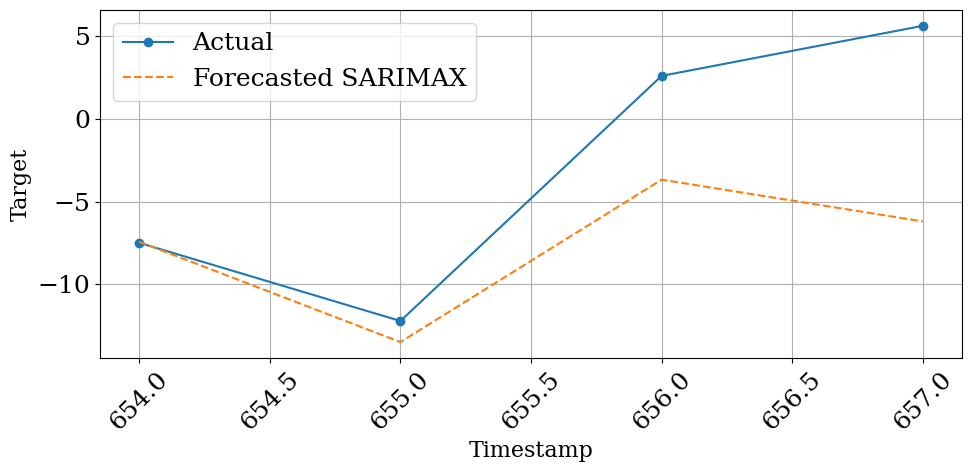

(4.85547428657323, 1.1593732566254902)

In [156]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


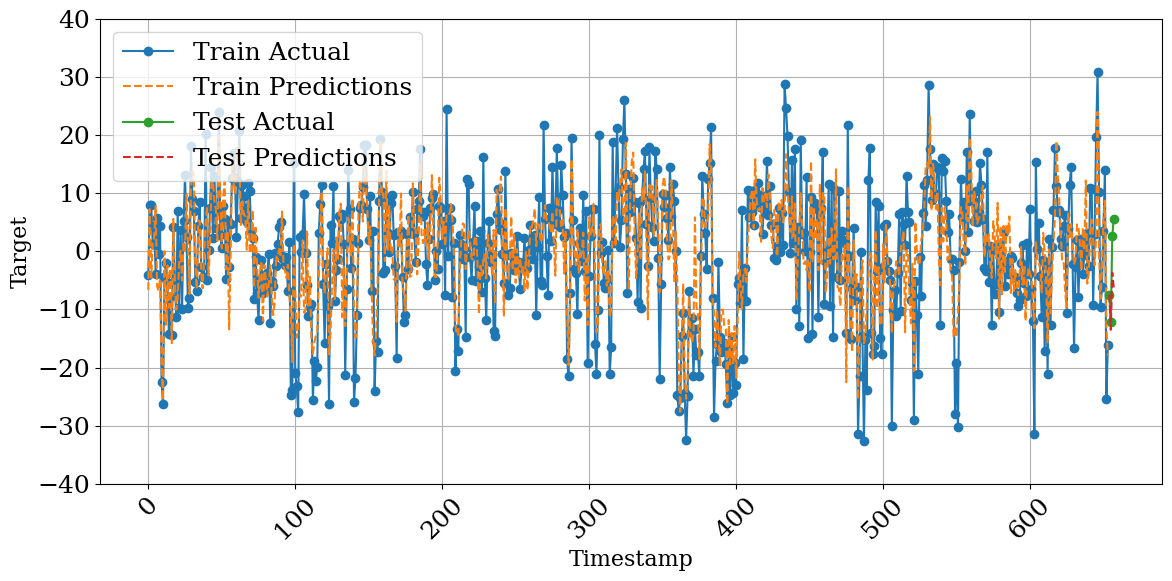

Train MAE: 5.8096
Train MAPE: 3.6344
Test MAE: 4.8555
Test MAPE: 1.1594


In [157]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     38.215255
1     29.095604
2     45.973073
3     37.206175
MAE: 4.74
MAPE: 9.81%


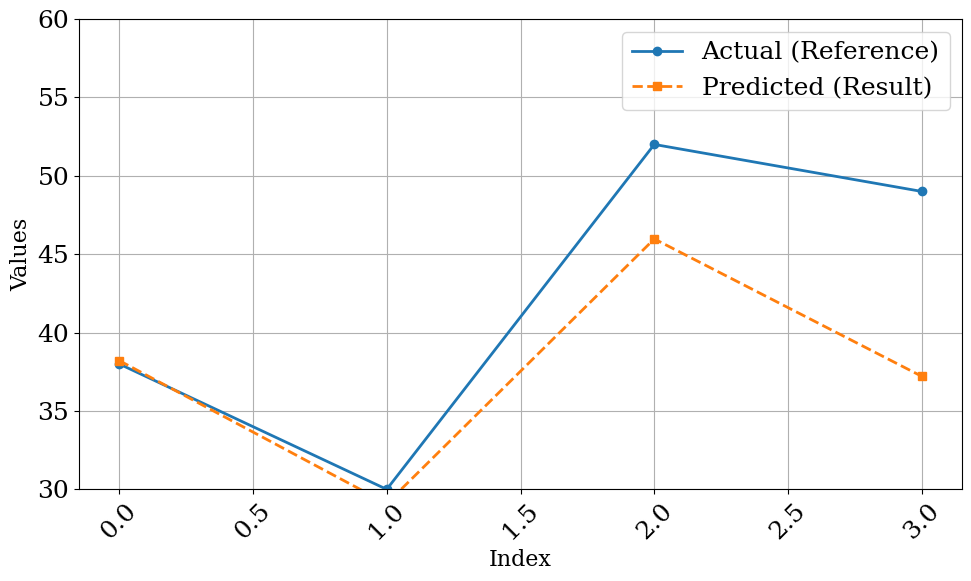

In [158]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w RFE', mae, mape)

In [159]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918
4,SARIMA w PSO Best,3.439248,0.07918
5,Statistical Dataset,0,0
6,SARIMA w RFE,4.735101,0.098101


#### pso dataset

In [160]:
train_data = data_psos[:-4]  # Last 4 rows for testing
test_data = data_psos[-4:]

In [161]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [162]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

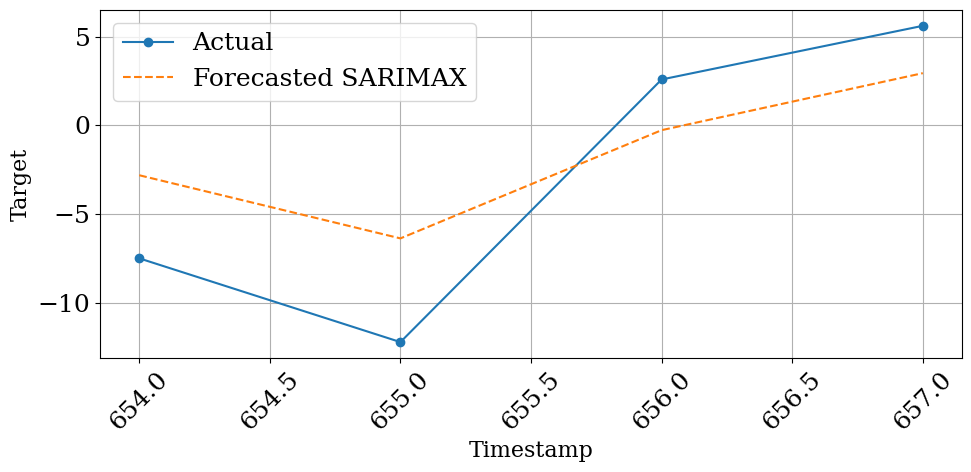

(4.014067244622324, 0.6705915576808855)

In [163]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


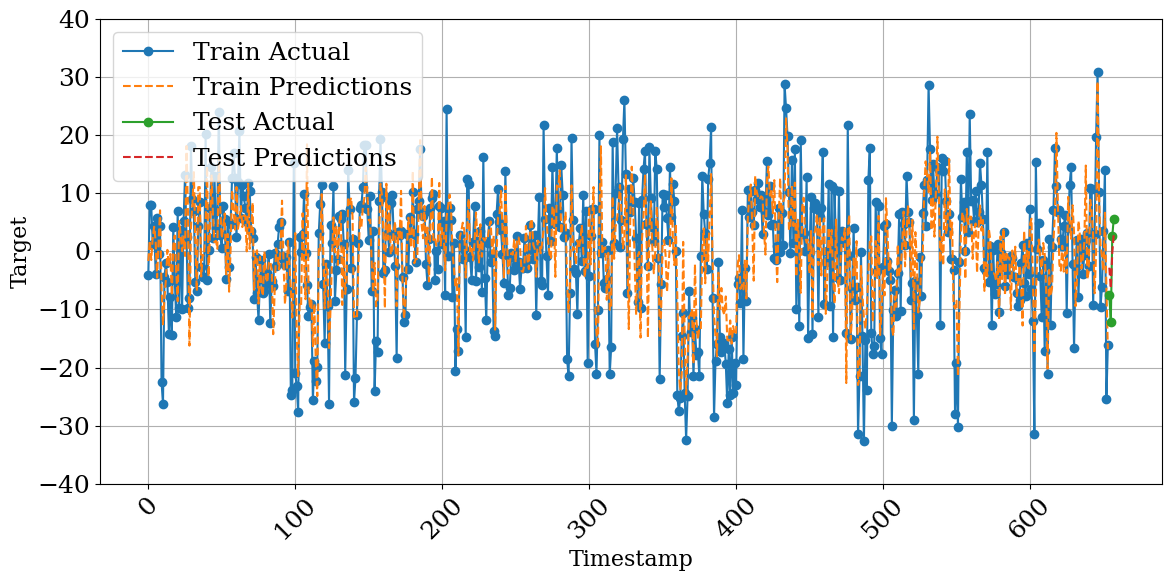

Train MAE: 6.3185
Train MAPE: 3.8651
Test MAE: 4.0141
Test MAPE: 0.6706


In [164]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     42.837401
1     36.215888
2     49.384348
3     46.354311
MAE: 4.08
MAPE: 10.97%


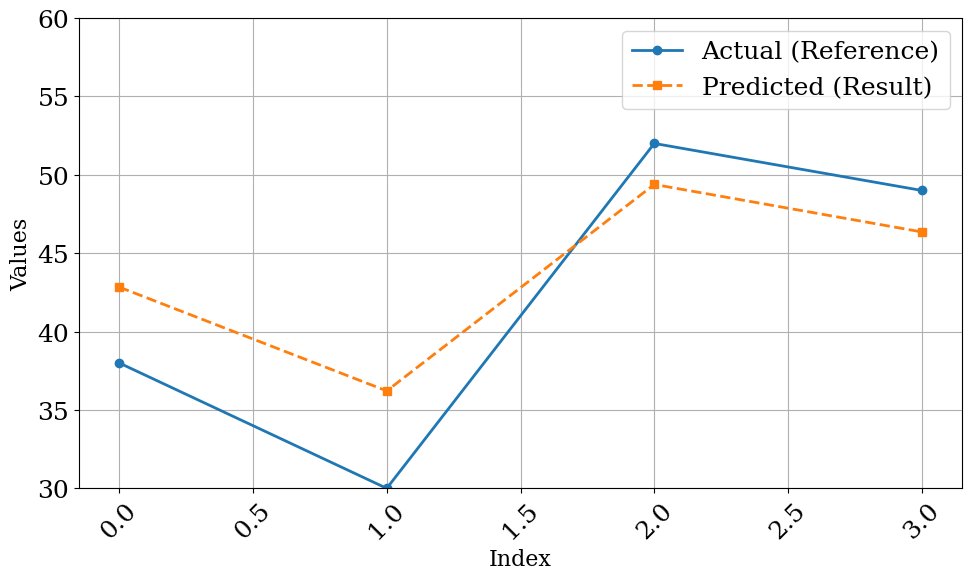

In [165]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w PSO', mae, mape)

In [166]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918
4,SARIMA w PSO Best,3.439248,0.07918
5,Statistical Dataset,0,0
6,SARIMA w RFE,4.735101,0.098101
7,SARIMA w PSO,4.078657,0.109698


#### pso_best dataset

In [167]:
train_data = data_psos_best[:-4]  # Last 4 rows for testing
test_data = data_psos_best[-4:]

In [168]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [169]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

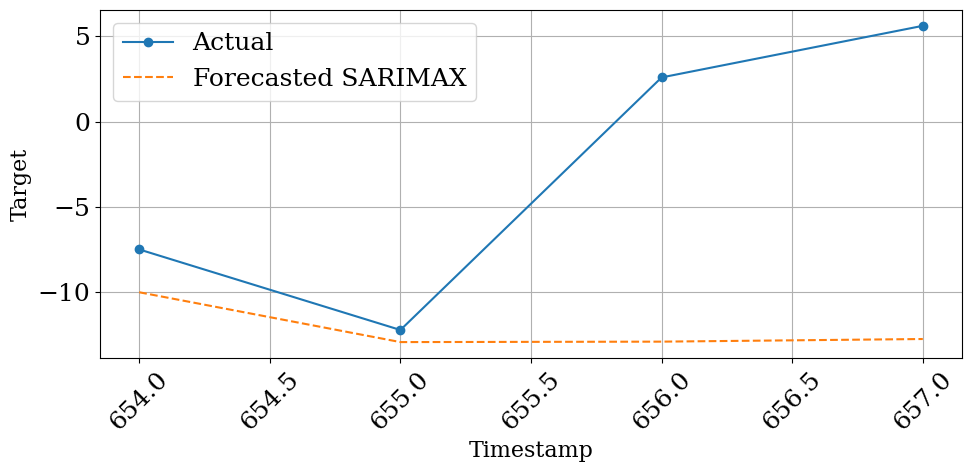

(9.266070977924459, 2.4105697456748922)

In [170]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


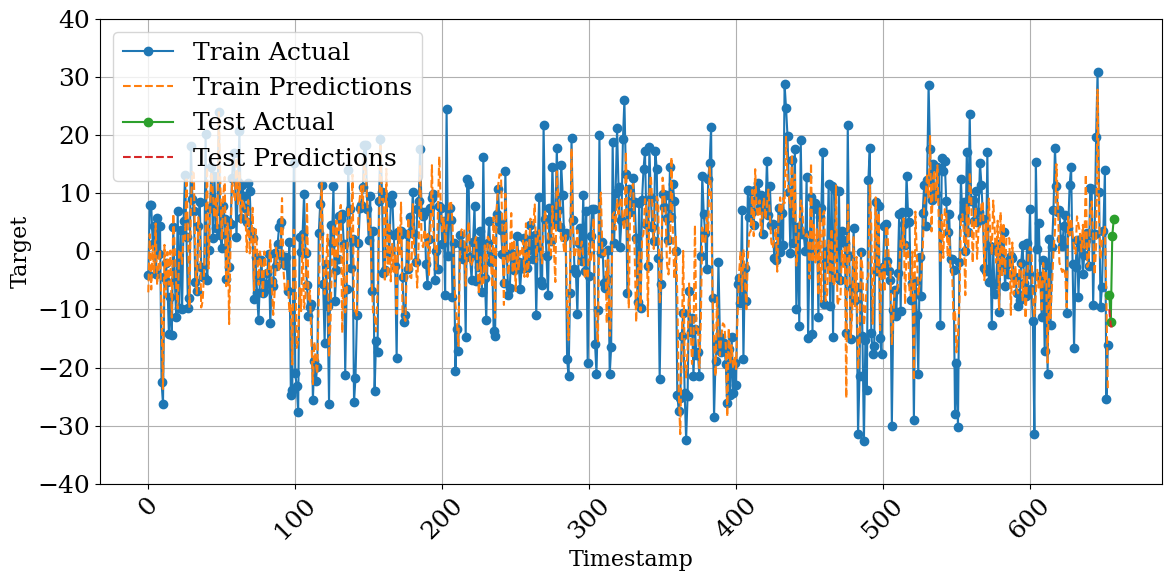

Train MAE: 6.0906
Train MAPE: 3.4438
Test MAE: 9.2661
Test MAPE: 2.4106


In [171]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     35.643172
1     29.661051
2     36.754605
3     30.664876
MAE: 9.07
MAPE: 18.52%


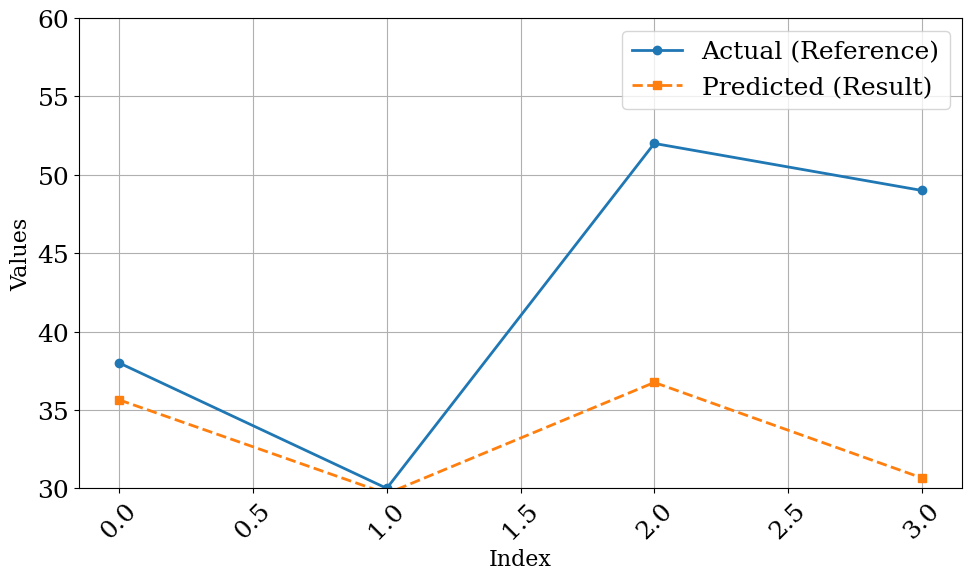

In [172]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w PSO Best', mae, mape)

In [173]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918
4,SARIMA w PSO Best,3.439248,0.07918
5,Statistical Dataset,0,0
6,SARIMA w RFE,4.735101,0.098101
7,SARIMA w PSO,4.078657,0.109698
8,SARIMA w PSO Best,9.069074,0.185172


In [174]:
end_time=time.time()

In [175]:
statistical_modelling=end_time-start_time

### COMBINED DATASET

In [176]:
start_time=time.time()

In [177]:
main_results = update_results(main_results, 'Combined Dataset','0' ,'0' )

In [178]:
data=datac

In [179]:
data

,betti_L1_H0,betti_L2_H0,betti_L1_H1,betti_L2_H1,silhouette_features_L1_H0_SI,silhouette_features_L1_H1_SI,L1_H0,Std_H0,Entropy_H0,dim_0_median_lifetime,...,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_0,Operation__energy_ratio_by_chunks__num_segments_10__segment_focus_1,Operation__count_above__t_0,Operation__fourier_entropy__bins_2,Operation__fourier_entropy__bins_3,Operation__fourier_entropy__bins_5,Operation__fourier_entropy__bins_10,Operation__fourier_entropy__bins_100,Operation__permutation_entropy__dimension_4__tau_1,Operation__mean_n_absolute_max__number_of_maxima_7
0,231,36.180105,0,0.00000,7.945403,0.000000,18495.358549,7.064659,6.171638,0.596196,...,0.050248,0.095645,0.625000,0.429323,0.983961,1.458319,1.844621,2.458311,2.780466,19.080239
1,213,33.481338,0,0.00000,8.022068,0.000000,18201.199435,6.357117,6.290207,0.501286,...,0.117910,0.047762,0.583333,0.617242,0.983961,1.351681,1.925121,2.458311,2.780466,19.080239
2,200,33.075671,0,0.00000,6.175045,0.000000,18199.538647,6.892422,6.114473,0.501286,...,0.125890,0.075231,0.583333,0.617242,0.983961,1.271181,1.711845,2.245035,2.846480,19.080239
3,201,32.908965,0,0.00000,6.903596,0.000000,18200.773051,6.850863,6.176156,0.511818,...,0.096498,0.082070,0.583333,0.617242,0.925129,1.306107,1.884871,2.564949,2.846480,19.080239
4,278,36.660606,0,0.00000,16.303287,0.000000,18204.922509,5.239300,6.637117,0.722078,...,0.051978,0.119120,0.583333,0.617242,0.925129,1.303876,1.671595,2.564949,2.780466,18.089667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,268,40.422766,0,0.00000,8.445050,0.000000,18533.236958,7.246619,6.026625,0.705450,...,0.091301,0.020501,0.541667,0.617242,0.858741,1.438883,1.991509,2.564949,2.375647,18.347899
654,305,42.836900,6,2.44949,11.541242,0.137897,18533.842489,6.894585,6.201800,0.820814,...,0.084076,0.019291,0.541667,0.617242,0.858741,1.438883,1.925121,2.564949,2.400563,19.129352
655,277,42.059482,6,2.44949,8.274008,0.137897,18533.842424,8.077916,5.850255,0.780672,...,0.022441,0.006277,0.541667,0.617242,0.925129,1.230932,1.818483,2.564949,2.400563,18.283331
656,280,41.496988,0,0.00000,9.478212,0.000000,18533.968890,7.714188,6.020489,0.716350,...,0.019407,0.005953,0.541667,0.617242,0.858741,1.377820,1.732659,2.351673,2.400563,18.500721


In [180]:
import pandas as pd

# Combine data_rfe and data_rfes into data_rfec
data_rfec = pd.concat([data_rfe, data_rfes], axis=1)

# Drop duplicate 'Target' columns if they exist
if 'Target' in data_rfec.columns:
    data_rfec = data_rfec.loc[:, ~data_rfec.columns.duplicated()]

# Combine data_pso and data_psos into data_psoc
data_psoc = pd.concat([data_pso, data_psos], axis=1)

# Drop duplicate 'Target' columns if they exist
if 'Target' in data_psoc.columns:
    data_psoc = data_psoc.loc[:, ~data_psoc.columns.duplicated()]
    
    
    
# Combine data_pso and data_psos into data_psoc
data_psoc_best = pd.concat([data_pso_best, data_psos_best], axis=1)

# Drop duplicate 'Target' columns if they exist
if 'Target' in data_psoc_best.columns:
    data_psoc_best = data_psoc_best.loc[:, ~data_psoc_best.columns.duplicated()]


In [181]:
data_rfec

,dim_0_median_lifetime,Target,Operation__skewness,Operation__count_above_mean,Operation__last_location_of_minimum,Operation__time_reversal_asymmetry_statistic__lag_1,Operation__cid_ce__normalize_False,Operation__quantile__q_0.3,Operation__autocorrelation__lag_2,Operation__autocorrelation__lag_3,...,"Operation__linear_trend__attr_""rvalue""","Operation__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""var""","Operation__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC""",Operation__number_crossing_m__m_-1,Operation__count_above__t_0,Operation__fourier_entropy__bins_2,Operation__permutation_entropy__dimension_4__tau_1
0,0.596196,-4.142840,-1.198499,15,0.666667,71.367052,76.457647,-1.285158,0.335404,0.134468,...,-0.500259,13.599913,39.155574,-3.998393,59.762545,-3.863124,10,0.625000,0.429323,2.780466
1,0.501286,8.043188,-1.132111,14,0.625000,-158.557182,77.251722,-4.233185,0.358753,0.132847,...,-0.514938,13.258616,32.136604,-3.998393,58.976407,-1.824514,11,0.583333,0.617242,2.780466
2,0.501286,7.962193,-1.135405,14,0.583333,-278.672695,77.891612,-4.233185,0.349715,0.056073,...,-0.432516,13.172868,94.399965,-3.741150,32.868325,-3.863376,12,0.583333,0.617242,2.846480
3,0.511818,1.249911,-1.164489,14,0.541667,-199.324046,77.818940,-4.233185,0.315859,0.050791,...,-0.315287,13.172868,122.102643,-3.741150,-37.915147,-1.477198,12,0.583333,0.617242,2.846480
4,0.722078,4.444332,-1.252528,15,0.500000,-150.014705,77.715563,-4.233185,0.304236,-0.008607,...,-0.216304,12.164508,129.363802,-2.575689,-38.161121,-2.530466,12,0.583333,0.617242,2.780466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,0.705450,-16.162745,0.289426,12,1.000000,678.116173,66.351080,-2.847018,-0.215597,-0.059346,...,0.190533,9.767177,37.597262,5.934479,90.895082,-0.760139,12,0.541667,0.617242,2.375647
654,0.820814,-7.492370,0.276702,13,0.958333,606.073613,65.437589,-4.077679,-0.264203,-0.060919,...,0.061366,10.532040,39.661991,5.475561,105.363546,-1.191205,12,0.541667,0.617242,2.400563
655,0.780672,-12.214303,0.333792,12,0.916667,1008.229381,64.534065,-4.077679,-0.208603,-0.165319,...,-0.096706,10.532040,23.357399,5.475561,101.748585,-2.645622,12,0.541667,0.617242,2.400563
656,0.716350,2.589885,0.358129,13,0.875000,1041.787677,64.539864,-6.323073,-0.133511,-0.034258,...,-0.194709,20.693331,62.562851,-9.237675,10.806445,-1.394208,11,0.541667,0.617242,2.400563


In [182]:
data_psoc

,dim_0_median_lifetime,Target,Operation__autocorrelation__lag_2,Operation__partial_autocorrelation__lag_2,"Operation__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","Operation__cwt_coefficients__coeff_8__w_2__widths_(2, 5, 10, 20)","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_0.8__ql_0.0","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_1.0__ql_0.0","Operation__fft_coefficient__attr_""real""__coeff_6","Operation__fft_coefficient__attr_""real""__coeff_7","Operation__fft_coefficient__attr_""real""__coeff_9","Operation__fft_coefficient__attr_""abs""__coeff_4","Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""max""",Operation__count_above__t_0,Operation__permutation_entropy__dimension_4__tau_1
0,0.596196,-4.142840,0.335404,0.316719,3.333692,13.276288,123.619419,105.864228,22.265140,13.047248,-3.890079,63.828842,-3.998393,0.625000,2.780466
1,0.501286,8.043188,0.358753,0.343395,8.174995,13.127178,114.859685,102.679284,12.378689,-78.858357,-0.416176,63.697280,-3.998393,0.583333,2.780466
2,0.501286,7.962193,0.349715,0.339711,12.636150,4.020585,108.667699,101.315747,-16.741785,32.545984,7.952376,66.195735,-3.741150,0.583333,2.846480
3,0.511818,1.249911,0.315859,0.310642,13.042162,-6.341978,114.859685,104.443174,-15.277289,60.199347,-10.760052,62.601949,-3.741150,0.583333,2.846480
4,0.722078,4.444332,0.304236,0.302306,15.312314,-8.346975,114.859685,104.954481,20.940202,-55.814250,21.557411,64.719582,-2.575689,0.583333,2.780466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,0.705450,-16.162745,-0.215597,-0.261118,-7.298451,-1.965109,28.236448,74.741312,-3.774934,3.116123,30.456692,61.253413,5.934479,0.541667,2.375647
654,0.820814,-7.492370,-0.264203,-0.389790,-9.296848,-2.515429,25.343294,74.224371,67.672676,-13.807358,-5.557579,63.329289,5.475561,0.541667,2.400563
655,0.780672,-12.214303,-0.208603,-0.372576,-5.228234,-1.207726,22.544420,73.859006,17.722735,15.617855,-15.099763,54.575444,5.475561,0.541667,2.400563
656,0.716350,2.589885,-0.133511,-0.308229,-4.112683,1.227378,22.518937,73.819562,-76.795026,-0.946325,24.491412,61.908999,-9.237675,0.541667,2.400563


In [183]:
data_psoc_best 

,dim_0_median_lifetime,Target,Operation__skewness,Operation__cid_ce__normalize_False,Operation__quantile__q_0.3,"Operation__agg_autocorrelation__f_agg_""median""__maxlag_40","Operation__cwt_coefficients__coeff_8__w_2__widths_(2, 5, 10, 20)",Operation__ar_coefficient__coeff_6__k_10,"Operation__change_quantiles__f_agg_""mean""__isabs_False__qh_0.6__ql_0.4","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_0.8__ql_0.4",...,"Operation__change_quantiles__f_agg_""var""__isabs_True__qh_0.8__ql_0.0","Operation__change_quantiles__f_agg_""var""__isabs_True__qh_1.0__ql_0.0",Operation__count_above_mean,Operation__binned_entropy__max_bins_10,"Operation__agg_linear_trend__attr_""slope""__chunk_len_10__f_agg_""var""",Operation__time_reversal_asymmetry_statistic__lag_1,Operation__partial_autocorrelation__lag_3,"Operation__change_quantiles__f_agg_""var""__isabs_False__qh_0.8__ql_0.0","Operation__linear_trend__attr_""rvalue""","Operation__augmented_dickey_fuller__attr_""teststat""__autolag_""AIC"""
0,0.596196,-4.142840,-1.198499,76.457647,-1.285158,-0.131139,13.276288,-0.237855,0.000000,0.000000,...,123.619419,105.864228,15,2.015165,59.762545,71.367052,0.050503,372.015436,-0.500259,-3.863124
1,0.501286,8.043188,-1.132111,77.251722,-4.233185,-0.182269,13.127178,-0.266603,0.000000,0.000000,...,114.859685,102.679284,14,2.015165,58.976407,-158.557182,0.051430,379.609038,-0.514938,-1.824514
2,0.501286,7.962193,-1.135405,77.891612,-4.233185,-0.058451,4.020585,-0.058524,0.000000,0.000000,...,108.667699,101.315747,14,2.023555,32.868325,-278.672695,-0.016258,365.732014,-0.432516,-3.863376
3,0.511818,1.249911,-1.164489,77.818940,-4.233185,0.026567,-6.341978,-0.039240,0.000000,0.000000,...,114.859685,104.443174,14,2.004637,-37.915147,-199.324046,0.005382,379.609038,-0.315287,-1.477198
4,0.722078,4.444332,-1.252528,77.715563,-4.233185,-0.008607,-8.346975,-0.108355,0.000000,0.000000,...,114.859685,104.954481,15,1.826590,-38.161121,-150.014705,-0.039366,379.609038,-0.216304,-2.530466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,0.705450,-16.162745,0.289426,66.351080,-2.847018,-0.100905,-1.965109,-1.259172,2.559060,0.375751,...,28.236448,74.741312,12,2.015165,90.895082,678.116173,0.046673,88.265326,0.190533,-0.760139
654,0.820814,-7.492370,0.276702,65.437589,-4.077679,-0.060919,-2.515429,-1.650338,2.559060,0.375751,...,25.343294,74.224371,13,2.082993,105.363546,606.073613,0.216005,76.642957,0.061366,-1.191205
655,0.780672,-12.214303,0.333792,64.534065,-4.077679,-0.042856,-1.207726,-0.766865,2.559060,0.375751,...,22.544420,73.859006,12,2.047032,101.748585,1008.229381,0.082314,70.032207,-0.096706,-2.645622
656,0.716350,2.589885,0.358129,64.539864,-6.323073,-0.057411,1.227378,-0.975978,2.559060,0.375751,...,22.518937,73.819562,13,2.087085,10.806445,1041.787677,0.181365,71.665790,-0.194709,-1.394208


#### rfe dataset

In [184]:
train_data = data_rfec[:-4]  # Last 4 rows for testing
test_data = data_rfec[-4:]

In [185]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [186]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

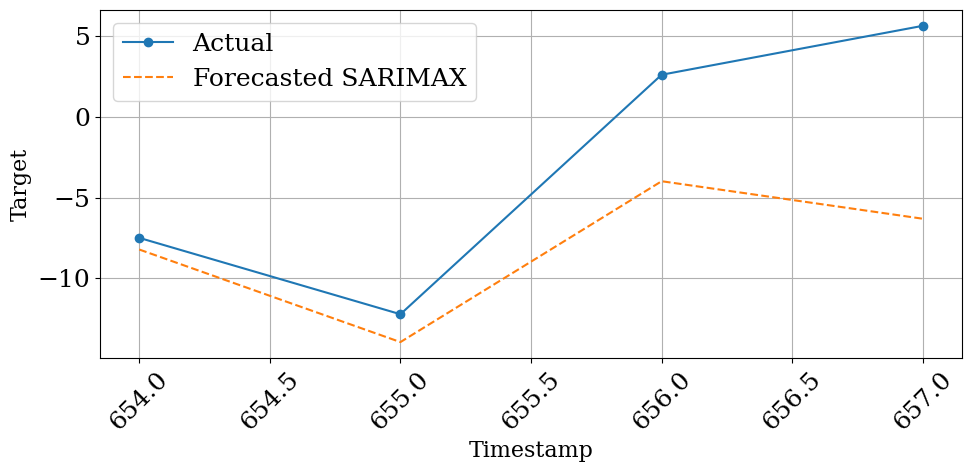

(5.237581863045942, 1.2255933490460342)

In [187]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


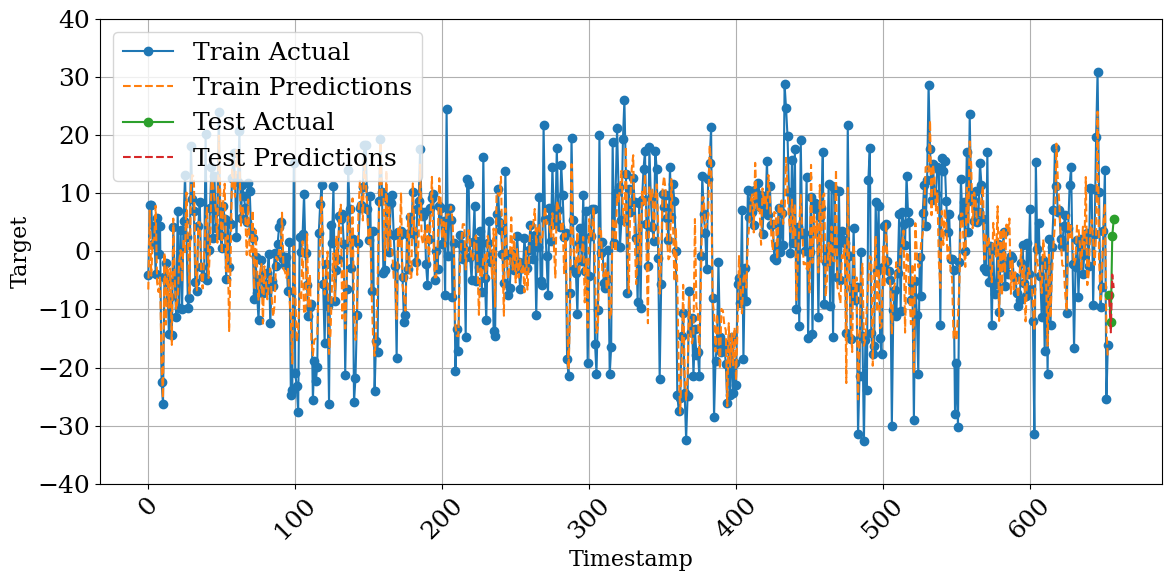

Train MAE: 5.8050
Train MAPE: 3.8612
Test MAE: 5.2376
Test MAPE: 1.2256


In [188]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     37.432851
1     28.647940
2     45.659970
3     37.096900
MAE: 5.04
MAPE: 10.62%


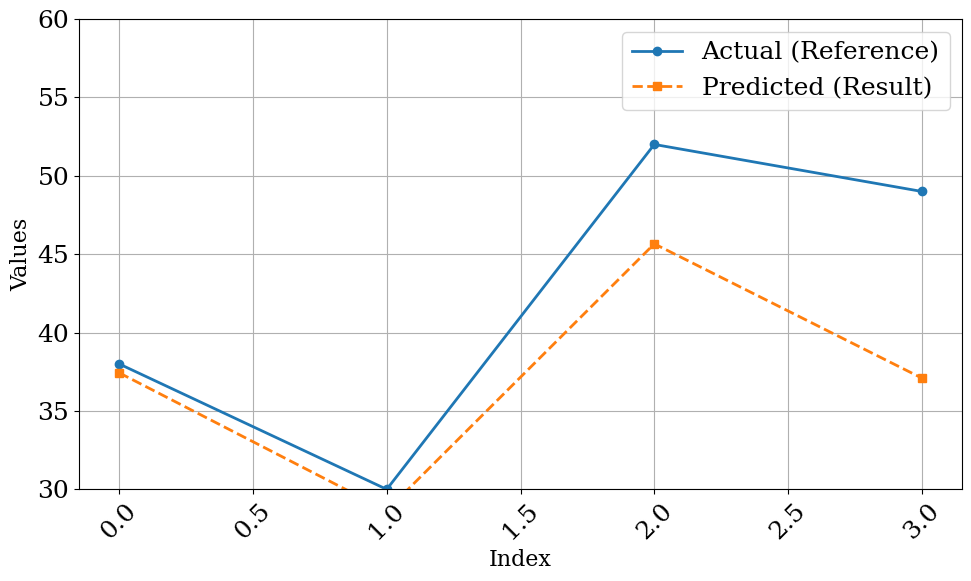

In [189]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w RFE', mae, mape)

In [190]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918
4,SARIMA w PSO Best,3.439248,0.07918
5,Statistical Dataset,0,0
6,SARIMA w RFE,4.735101,0.098101
7,SARIMA w PSO,4.078657,0.109698
8,SARIMA w PSO Best,9.069074,0.185172
9,Combined Dataset,0,0


#### pso dataset

In [191]:
train_data = data_psoc[:-4]  # Last 4 rows for testing
test_data = data_psoc[-4:]

In [192]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [193]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

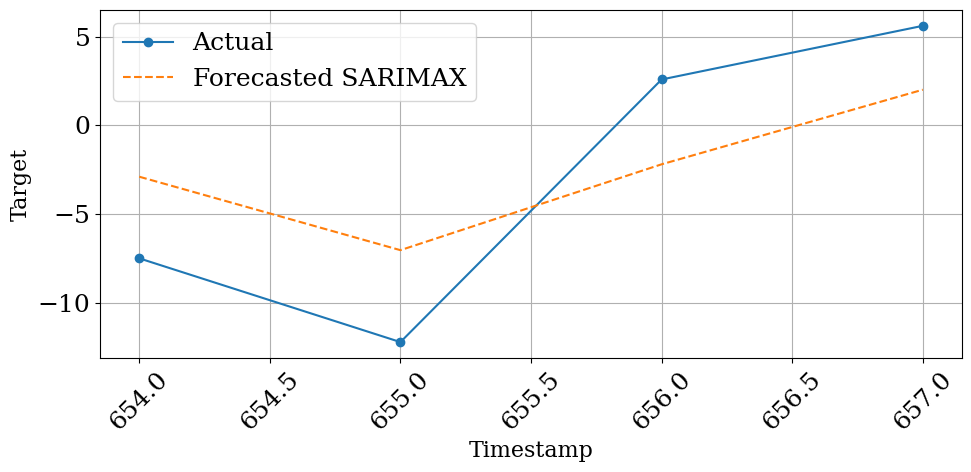

(4.541811127590566, 0.8815402596795394)

In [194]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


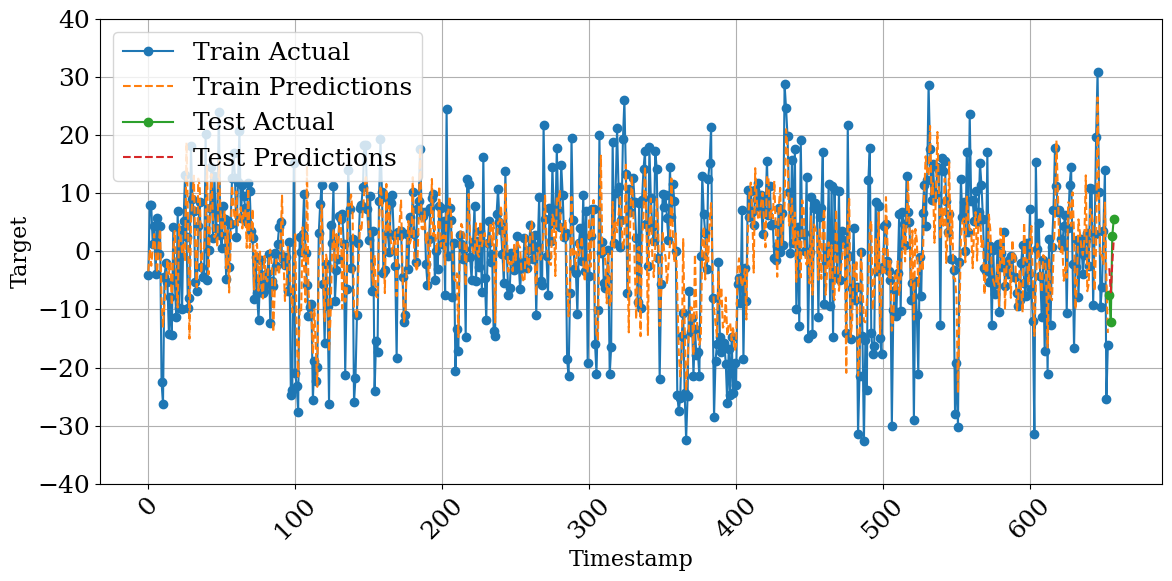

Train MAE: 6.3265
Train MAPE: 3.4799
Test MAE: 4.5418
Test MAPE: 0.8815


In [195]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     42.755136
1     35.551845
2     47.460136
3     45.421240
MAE: 4.61
MAPE: 11.76%


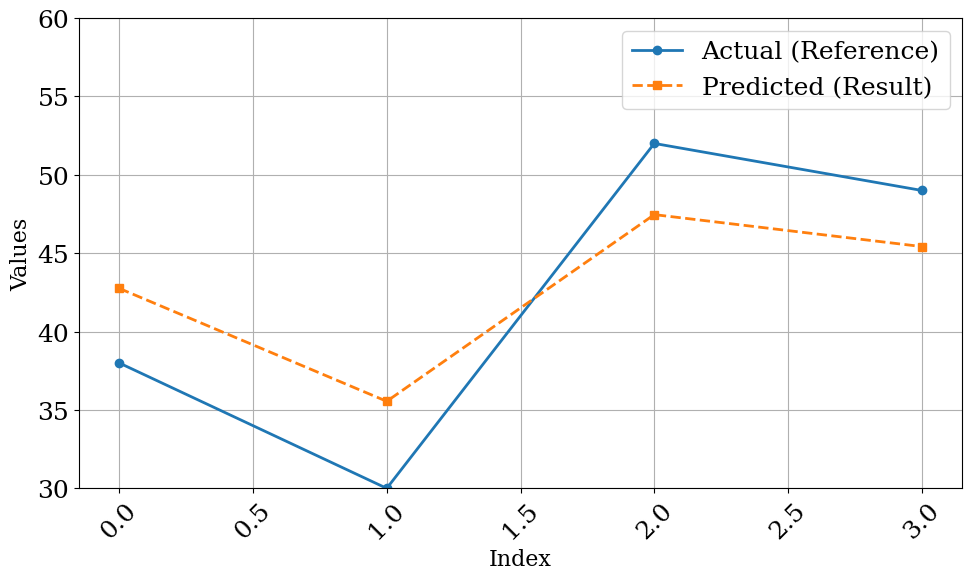

In [196]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w PSO', mae, mape)

In [197]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918
4,SARIMA w PSO Best,3.439248,0.07918
5,Statistical Dataset,0,0
6,SARIMA w RFE,4.735101,0.098101
7,SARIMA w PSO,4.078657,0.109698
8,SARIMA w PSO Best,9.069074,0.185172
9,Combined Dataset,0,0


#### pso_best dataset

In [198]:
train_data = data_psoc_best[:-4]  # Last 4 rows for testing
test_data = data_psoc_best[-4:]

In [199]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [200]:
exog_train=selected_columns_train
exog_test=selected_columns_test 

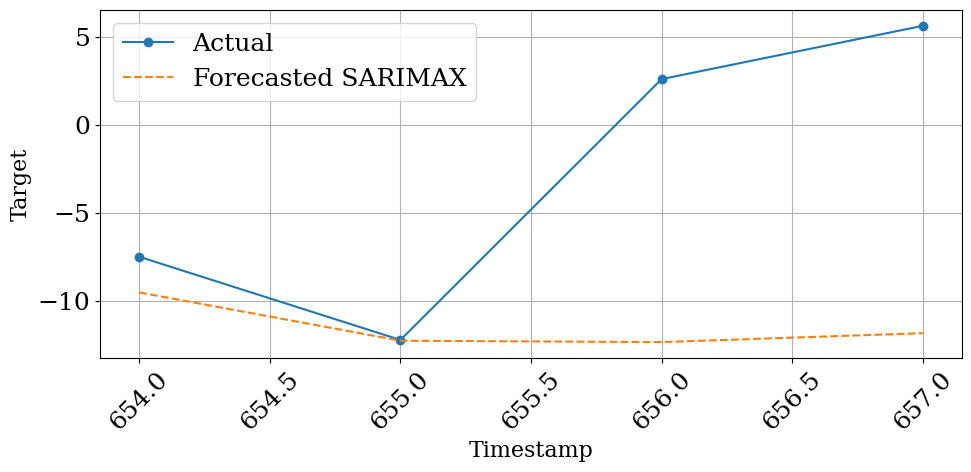

(8.608966776711018, 2.285763995465113)

In [201]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Output the MSE and MAPE values
sarima_mse, sarima_mape


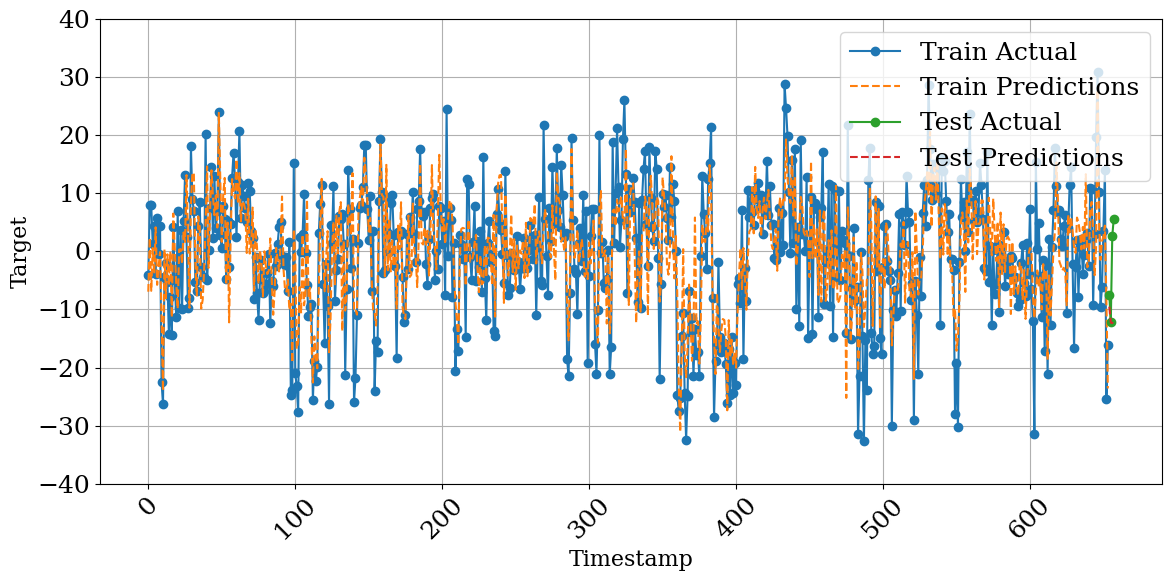

Train MAE: 6.0932
Train MAPE: 3.4913
Test MAE: 8.6090
Test MAPE: 2.2858


In [202]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'], 
                order=(2, 0, 0), 
                seasonal_order=(1, 0, 1, 8), 
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# In-sample predictions for the training set
train_predictions = sarimax_results.predict(start=train_data.index[0], 
                                             end=train_data.index[-1], 
                                             exog=exog_train)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
test_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics for the training set
train_mae = mean_absolute_error(train_data['Target'], train_predictions)
train_mape = mean_absolute_percentage_error(train_data['Target'], train_predictions)

# Calculate evaluation metrics for the test set
test_mae = mean_absolute_error(test_data['Target'], test_predictions)
test_mape = mean_absolute_percentage_error(test_data['Target'], test_predictions)

# Plot the results: actual and predictions for both train and test data
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Target'], label='Train Actual', marker='o')
plt.plot(train_data.index, train_predictions, label='Train Predictions', linestyle='--')
plt.plot(test_data.index, test_data['Target'], label='Test Actual', marker='o')
plt.plot(test_data.index, test_predictions, label='Test Predictions', linestyle='--')
 
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-40, 40)
plt.show()

# Output the evaluation metrics
print("Train MAE: {:.4f}".format(train_mae))
print("Train MAPE: {:.4f}".format(train_mape))
print("Test MAE: {:.4f}".format(test_mae))
print("Test MAPE: {:.4f}".format(test_mape))


   Combined_Sum
0     36.130142
1     30.326337
2     37.316416
3     31.579227
MAE: 8.58
MAPE: 17.45%


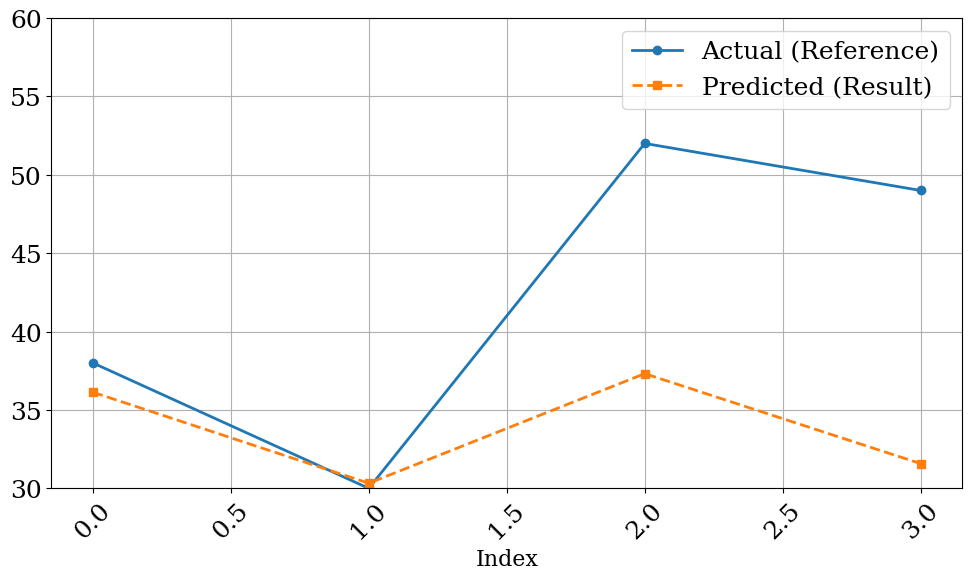

In [203]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual (Reference)', marker='o', linestyle='-', linewidth=2)
plt.plot(predicted.index, predicted, label='Predicted (Result)', marker='s', linestyle='--', linewidth=2)
 
plt.xlabel('Index')
plt.ylabel
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

main_results = update_results(main_results, 'SARIMA w PSO Best', mae, mape)

In [204]:
main_results

,Model_Name,MAE,MAPE
0,Topological Dataset,0,0
1,SARIMA W NO FEATURE,3.191193,0.079559
2,SARIMA w RFE,3.439248,0.07918
3,SARIMA w PSO,3.439248,0.07918
4,SARIMA w PSO Best,3.439248,0.07918
5,Statistical Dataset,0,0
6,SARIMA w RFE,4.735101,0.098101
7,SARIMA w PSO,4.078657,0.109698
8,SARIMA w PSO Best,9.069074,0.185172
9,Combined Dataset,0,0


In [205]:
from datetime import datetime
# Define your custom name
custom_name = "resultsH1"

# Get the current datetime and format it
current_datetime = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Create the filename by concatenating the datetime string and the custom name
filename = f"{current_datetime}_{custom_name}.xlsx"

# Save the DataFrame to an Excel file with the constructed filename
main_results.to_excel(filename, index=False)

print(f"DataFrame saved to {filename}")

DataFrame saved to 2025-03-24_11-23-00_resultsH1.xlsx


In [206]:
end_time=time.time()

In [207]:
combined_modelling=end_time-start_time

In [208]:
topological_modelling

13.819721698760986

In [209]:
statistical_modelling

63.14299035072327

In [210]:
combined_modelling

69.4669177532196

In [211]:
statistical_ext

-203.9131178855896

In [212]:
topological_ext

-65.85038876533508

In [213]:
statistical_elim

6799.417778253555

In [214]:
topological_elim

13.113034963607788